In [623]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from itertools import product
from dbnomics import fetch_series
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from arch import arch_model
from scipy.stats import chi2
from scipy.stats import t
from scipy.stats import norm
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression


In [522]:
# Harmonized Japan CPI
df1 = fetch_series('IMF/CPI/M.JP.PCPI_IX')
df1.to_csv('data.csv')

In [523]:
df1 = pd.read_csv('data.csv', index_col='period')
japanCPI = df1['value']
japanCPI.index = pd.to_datetime(japanCPI.index)
japanCPI = japanCPI.dropna()


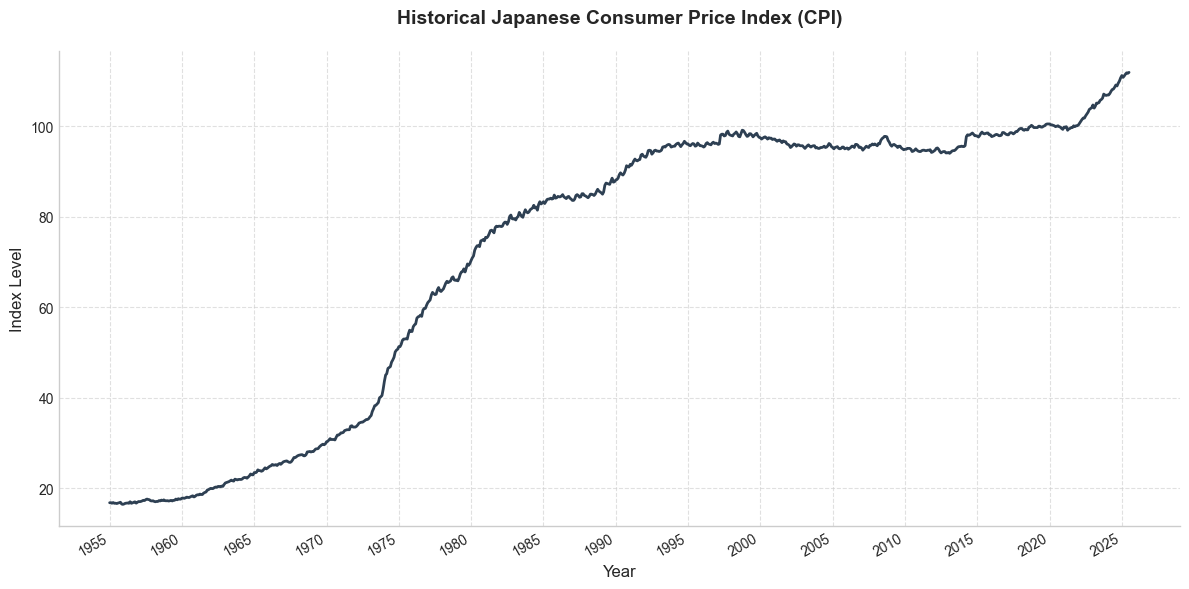

In [524]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(japanCPI.index, japanCPI, color='#2E4053', linewidth=2, label='Japan CPI')
ax.xaxis.set_major_locator(mdates.YearLocator(5)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

ax.set_title('Historical Japanese Consumer Price Index (CPI)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Index Level', fontsize=12)
ax.set_xlabel('Year', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [525]:
def run_adf_test(series, name):
    print(f"--- ADF Test Results for: {name} ---")
    
    # We test the 4 most common forms:
    # 'n'  : No constant, no trend
    # 'c'  : Constant only (default)
    # 'ct' : Constant and trend
    # 'ctt' : Constant and quadratic trend

    
    for regression_type in ['n', 'c', 'ct', 'ctt']:
        result = adfuller(series.dropna(), regression=regression_type, autolag='BIC')
        
        print(f"\nForm: {regression_type}")
        print(f'ADF Statistic: {result[0]:.4f}')
        print(f'p-value: {result[1]:.4f}')
        print('Critical Values:')
        for key, value in result[4].items():
            print(f'\t{key}: {value:.4f}')

run_adf_test(japanCPI, "Japan CPI")

--- ADF Test Results for: Japan CPI ---

Form: n
ADF Statistic: 1.2701
p-value: 0.9477
Critical Values:
	1%: -2.5684
	5%: -1.9413
	10%: -1.6165

Form: c
ADF Statistic: -1.3937
p-value: 0.5853
Critical Values:
	1%: -3.4382
	5%: -2.8650
	10%: -2.5686

Form: ct
ADF Statistic: -1.6634
p-value: 0.7666
Critical Values:
	1%: -3.9697
	5%: -3.4158
	10%: -3.1302

Form: ctt
ADF Statistic: -2.1804
p-value: 0.7393
Critical Values:
	1%: -4.3851
	5%: -3.8395
	10%: -3.5577


The ADF test performed highlights that we don't reject the null for Ho. We've used the 4 main deterministic forms no constants, constants, constant and trend, constant and quadratic trend.

As a result, we can say that the serie is non stationarity, and the source is stochastic, not deterministic.  
We will have to difference the serie.

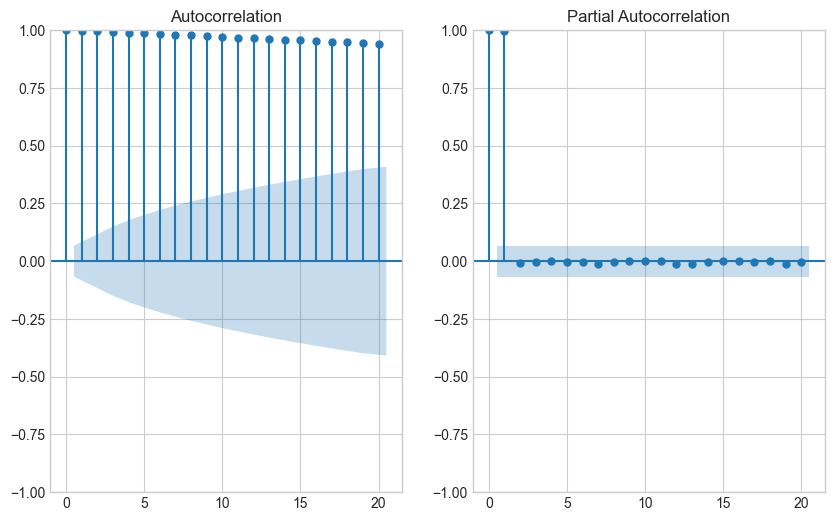

In [526]:
lag = 20
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(japanCPI, lags=lag, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(japanCPI, lags=lag, ax=ax2, alpha=0.05)

Just as a complementary visual approach, the ACF of the raw time serie exhibits a very slow decaying behavior, characteristic of non stationarry series.

We will now difference the serie and analyse whether the new serie is stationarry or there are other issues such as seasonality.

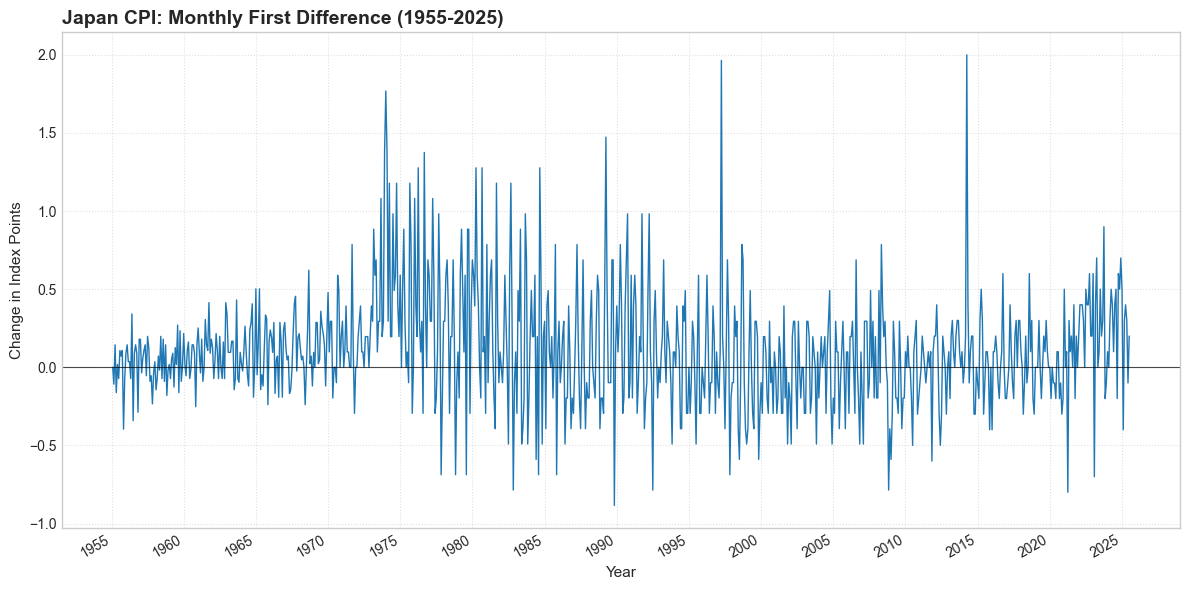

In [527]:
japanCPI_diff = japanCPI.diff()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(japanCPI_diff.index, japanCPI_diff, color='#1F77B4', linewidth=1, label='Monthly Change')
ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)

ax.xaxis.set_major_locator(mdates.YearLocator(5)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate() 

# 6. Add Titles and Labels
ax.set_title('Japan CPI: Monthly First Difference (1955-2025)', fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel('Change in Index Points', fontsize=11)
ax.set_xlabel('Year', fontsize=11)

ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [528]:
run_adf_test(japanCPI_diff, "Japan CPI")

--- ADF Test Results for: Japan CPI ---

Form: n
ADF Statistic: -2.3779
p-value: 0.0168
Critical Values:
	1%: -2.5684
	5%: -1.9413
	10%: -1.6165

Form: c
ADF Statistic: -3.1697
p-value: 0.0218
Critical Values:
	1%: -3.4382
	5%: -2.8650
	10%: -2.5686

Form: ct
ADF Statistic: -3.2634
p-value: 0.0725
Critical Values:
	1%: -3.9697
	5%: -3.4158
	10%: -3.1302

Form: ctt
ADF Statistic: -3.1870
p-value: 0.2142
Critical Values:
	1%: -4.3851
	5%: -3.8395
	10%: -3.5577


We can see that we reject the test for the case without constant (pure AR), and the test with constant. 
However, it seems the linear and quadratic trends are not rejected.

This is probably an overfitting of the test, as we are working with a differenced time serie.  
Very rare that it exhibits linear or quadratic trend. Graphically also we don't identify such trend.

In [529]:
lag = 5
results = sm.stats.diagnostic.acorr_ljungbox(japanCPI_diff[1:], lags=lag)
print(f"\nLag: {lag}")
print(f'LjungBox Statistic: {results}')
    


Lag: 5
LjungBox Statistic:      lb_stat     lb_pvalue
1  35.981625  1.991871e-09
2  41.366154  1.041008e-09
3  41.397592  5.385046e-09
4  50.752115  2.514943e-10
5  85.292196  6.537350e-17


We've performed the LjungBox test until lag 20, and everytime the pvalue is lower than 5%, meaning we reject the null. 

The time serie is not a White Noise, there definetly is autocorrelation to model, and we will use ARMA framework to do so.

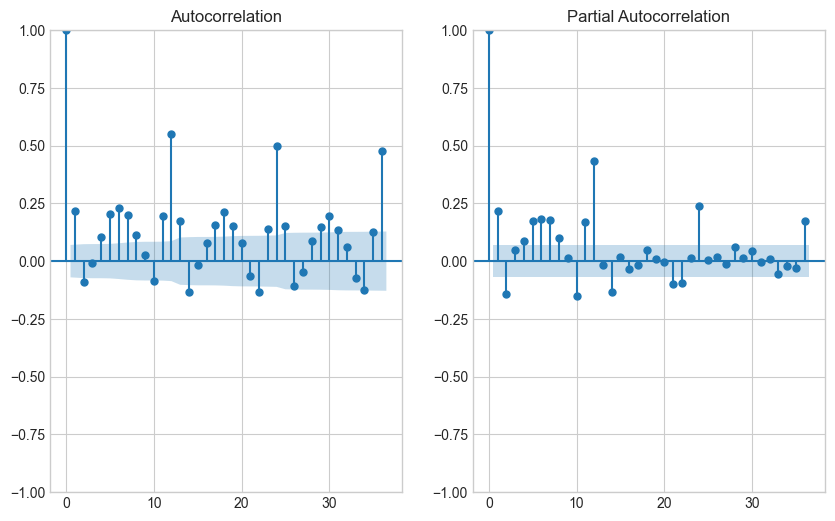

In [530]:
japanCPI_diff = japanCPI_diff.dropna()
end_date ='2019-12-01'

# In Sample Model
japanCPI_diff_in_sample = japanCPI_diff.loc[:end_date]
japanCPI_in_sample = japanCPI.loc[:end_date]

lag = 36
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(japanCPI_diff_in_sample, lags=lag, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(japanCPI_diff_in_sample, lags=lag, ax=ax2, alpha=0.05)

Analysing the ACF and PACF of the differenced time serie for the "in sample part", we can directly identify a lot of spikes, with the biggest ones at lag 12, 24, 36 which suggets a strong seasonality. Additionally, the ACF exhibits a very slow decay for these lags 12, 24 36.  
We might have seasonal unit root, leading to the need of seasonal differencing.  

Before moving to the blind estimation of several models, we will try to verify whether the double differencing (non-seasonal and seasonal is relevant and justified).

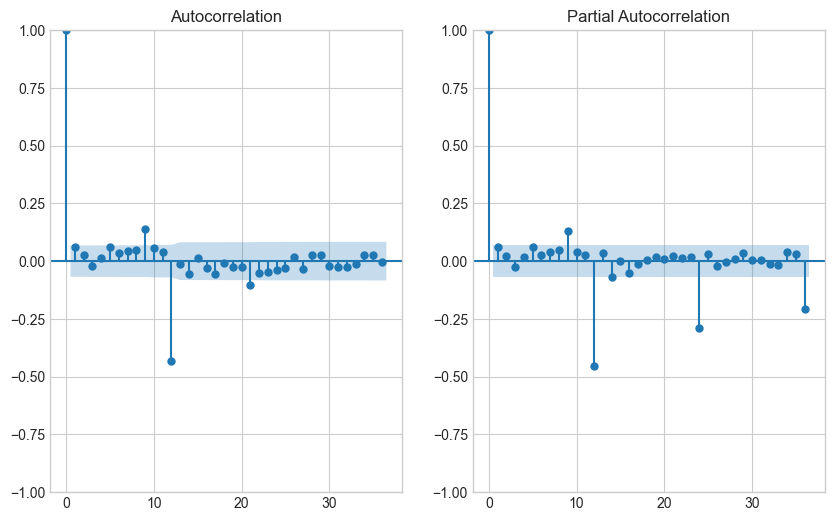

In [531]:
japanCPI_double_diff = japanCPI.diff().diff(12).dropna()

lag = 36
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(japanCPI_double_diff, lags=lag, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(japanCPI_double_diff, lags=lag, ax=ax2, alpha=0.05)


We see that applying both the non-seasonal and the seasonal differencing allows to capture the slow decay of the terms in lag 12, 24, 36, thus correcting for seasonal unit root. We now have only 1 big spike for 12 months, which shows that there is still seasonalitity, but a simple seasonal MA component could be able to capture it.

## Models estimation

We will try several models for p and q orders between 0 and 4.
Additionally, on the seasonal part, we will try first to use a $(0,1,0)_{12}$ component to capture the seasonality.   








In [532]:
ar_order = range(0, 3) 
ma_order = range(0, 3)

arma_res = []

for p, q in product(ar_order, ma_order):
    try:
        model = sm.tsa.SARIMAX(
            japanCPI, 
            order=(p, 1, q), 
            seasonal_order=(0, 1, 1, 12), 
            enforce_stationarity=False, 
            enforce_invertibility=False,
        ).fit(disp=False)
        
        arma_res.append([p, q, model.aic, model.bic])
    except Exception as e:
        arma_res.append([p, q, np.nan, np.nan])

res = pd.DataFrame(arma_res, columns=['p', 'q', 'AIC', 'BIC'])

print(res.to_string(index=False))

 p  q        AIC        BIC
 0  0 287.954716 297.375763
 0  1 274.564194 288.692107
 0  2 273.596657 292.428993
 1  0 271.984269 286.115839
 1  1 238.874810 257.712027
 1  2 241.097812 264.638232
 2  0 270.654753 289.496846
 2  1 275.684614 299.231136
 2  2 240.853400 269.101904


In [533]:
# 1. On calcule le rang pour chaque critère (1 = le meilleur)
res['rank_AIC'] = res['AIC'].rank(ascending=True)
res['rank_BIC'] = res['BIC'].rank(ascending=True)

# 2. On additionne les rangs
res['Combined_Rank'] = res['rank_AIC'] + res['rank_BIC']

# 3. On trie par le rang combiné le plus petit
res_sorted = res.sort_values('Combined_Rank').reset_index(drop=True)

#print(res_sorted[['p', 'q', 'Q_seas', 'AIC', 'BIC', 'Combined_Rank']].head(10).to_string(index=False))
print(res_sorted[['p', 'q', 'AIC', 'BIC', 'Combined_Rank']].head(10).to_string(index=False))

 p  q        AIC        BIC  Combined_Rank
 1  1 238.874810 257.712027            2.0
 1  2 241.097812 264.638232            5.0
 2  2 240.853400 269.101904            5.0
 1  0 271.984269 286.115839            9.0
 2  0 270.654753 289.496846           10.0
 0  1 274.564194 288.692107           12.0
 0  2 273.596657 292.428993           13.0
 0  0 287.954716 297.375763           17.0
 2  1 275.684614 299.231136           17.0


The model that has the lower coupled values for AIC and BIC is the SARIMA(1,1,1)(0,1,1).  
We will therefore retain this model and try to see if he passes the validation steps.


In [534]:
model1 = sm.tsa.SARIMAX(
            japanCPI_diff_in_sample, 
            order=(1, 1, 1), 
            seasonal_order=(0, 1, 1, 12),
            enforce_stationarity=False, 
            enforce_invertibility=False,
        ).fit(disp=False)

print(model1.summary())



                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  779
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -101.037
Date:                            Tue, 23 Dec 2025   AIC                            210.074
Time:                                    00:23:37   BIC                            228.565
Sample:                                02-01-1955   HQIC                           217.198
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0521      0.033      1.567      0.117      -0.013       0.117
ma.L1         -0.9328      0.012   

We can note that the AR coefficient is slightly not statistically significant.  
It seems that most of the behavior of this time serie is explained by the seasonal MA(12) and the cimple MA components that are very significant.

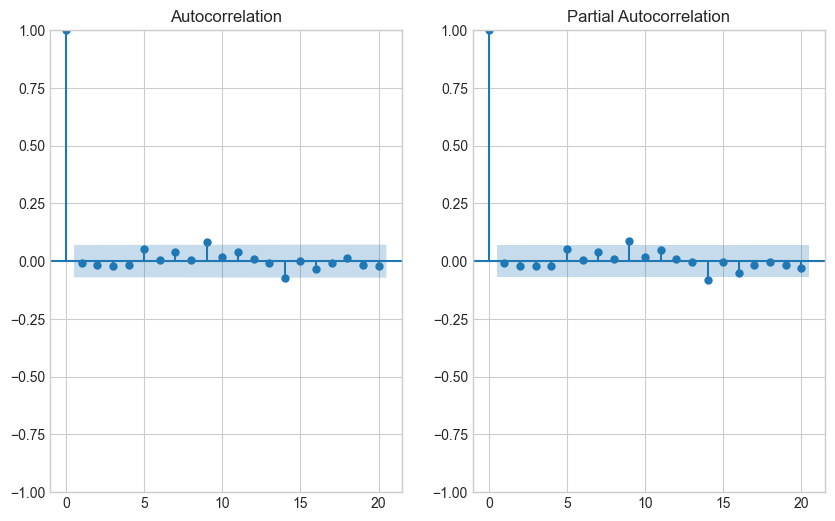

In [535]:
# Validation
residuals = model1.resid

fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(residuals, lags=20, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(residuals, lags=20, ax=ax2, alpha=0.05)

Graphically, we can see that the residuals have an ACF and PACF which is close to a White Noise.  
We have some values at lag 9 and 14 which are very close to the confidence interval, and that we may reject, but reality is never perfect.   
We will test this statistically now.

In [536]:
lb_in = sm.stats.diagnostic.acorr_ljungbox(residuals, lags=[15])
jb_in = sm.stats.stattools.jarque_bera(residuals, axis=0)
print(f'''Ljung Box Test p-value : {lb_in['lb_pvalue']}''')
print('\n')
print(f'Jarque Bera p-value : {jb_in[1]}')

Ljung Box Test p-value : 15    0.393214
Name: lb_pvalue, dtype: float64


Jarque Bera p-value : 4.7745948174577816e-119


Here we can see statistically that we don't reject the Ljung Box test, meaning we don't have remaining autocorelation in the residuals, which is a good thing in terms of specification and validity of our model.  
However, the residuals are clearly not normally distributed.

In order to finalise the specification analysis and test for homoskedasticity, we will test the presence of Arch effet using Ljung Box test on squared reiduals.

In [537]:
arch_effect_in = sm.stats.diagnostic.acorr_ljungbox(residuals**2, lags=[15])
print(arch_effect_in)

      lb_stat  lb_pvalue
15  26.840152   0.030066


We clearly see that we have an Arch effet in our residuals, as the null hypothesis of homoskedasticity is rejected.  
There is heteroskedaticity, which is coherent as we're  working with CPI data which are base on financial market data where variance is not constant trhough time.  
We will therefore use the Garch framework to model it.


In [538]:
orders = [(1, 0), (1, 1), (0,1)]
garch_results = []

for p, q in orders:
    try:
        # mean='Zero' because previous model SARIMA will be used to treat the mean
        model = arch_model(residuals, vol='GARCH', p=p, q=q, mean='Zero', dist='normal')
        res = model.fit(disp='off')
        
        garch_results.append({
            'Order (ARCH p, GARCH q)': f'({p},{q})',
            'AIC': res.aic,
            'BIC': res.bic,
            'Log-Likelihood': res.loglikelihood
        })
    except Exception as e:
        print(f"Erreur pour l'ordre ({p},{q}): {e}")

# Création du tableau comparatif
df_garch = pd.DataFrame(garch_results)
print(df_garch)

Erreur pour l'ordre (0,1): One of p or o must be strictly positive
  Order (ARCH p, GARCH q)         AIC         BIC  Log-Likelihood
0                   (1,0)  166.394205  175.710227      -81.197103
1                   (1,1)  139.097561  153.071594      -66.548781


By comparing both AIC and BIC for the two models, we can see that Garch(1,1) performs better, as we have lower AIC and BIC.

In [539]:
model2 = arch_model(residuals, p=1, o=0, q=1, mean='Zero', dist='normal').fit(disp='off')
print(model2.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -66.5488
Distribution:                  Normal   AIC:                           139.098
Method:            Maximum Likelihood   BIC:                           153.072
                                        No. Observations:                  779
Date:                Tue, Dec 23 2025   Df Residuals:                      779
Time:                        00:23:37   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      4.3448e-04  3.372e-04      1.289      0.198 

Note that we're not interested in the mean equation here, we've already modelize it before. 
So that is normal to have a R-squared equal to 0. 

The results of the optimization tell us that the Garch effect is very strong, as we have a beta coefficient which is statistically significant. However, the constant and alpha coefficient have p-values close to 10% but higher. Meaning they are not statistically significant.  

However, the BIC and AIC of the model is a lot better than a simple ARCH(1) model tested before, so we will keep the Garch(1,1) form.  
A coefficient that is slightly not significant must not automatically be taken out sometimes.

We will now test for validation of the model.

In [540]:
lag = 15
lb_garch_in = sm.stats.diagnostic.acorr_ljungbox(model2.std_resid, lags=[lag])
jb_garch_in = sm.stats.stattools.jarque_bera(model2.std_resid, axis=0)

lb_garch_sq_in = sm.stats.diagnostic.acorr_ljungbox(model2.std_resid**2, lags=[lag])


print(f'''Ljung Box Test on residuals - p-value : {lb_garch_in['lb_pvalue']}''')
print(f'Jarque Bera on residuals - p-value : {jb_garch_in[1]}')
print(f'''Ljung Box Test on squared residuals - p-value : {lb_garch_sq_in['lb_pvalue']}''')

Ljung Box Test on residuals - p-value : 15    0.40136
Name: lb_pvalue, dtype: float64
Jarque Bera on residuals - p-value : 5.7805677406728934e-291
Ljung Box Test on squared residuals - p-value : 15    0.978832
Name: lb_pvalue, dtype: float64


As a result, we can see that the LjungBox test on the residuals is not rejected as before, but additionally, we've been able to correct for homoskedasticity through the use of Garch model for the volatility of our time serie as the LjungBox test on squared residuals is not rejected anymore (p-val=0.89)

To Conclude we retain the following model : $SARIMA(1,1,1)(0,1,1)_{12}-GARCH(1,1)$

# Recursive Forecast

In [541]:
out_of_sample_indices = japanCPI['2020-01-01':'2025-07-01'].index
forecasts = []
actuals = []
lower_bounds = []
upper_bounds = []

for i, current_date in enumerate(out_of_sample_indices):
    train_data = japanCPI[:current_date].iloc[:-1] 
    actual_val = japanCPI.loc[current_date]
    
    try:
        sarima_model = sm.tsa.SARIMAX(
            train_data,
            order=(1, 1, 1), 
            seasonal_order=(0, 1, 1, 12), 
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        
        # This forecast is directly in level of CPI
        sarima_forecast = sarima_model.get_forecast(steps=1).predicted_mean.iloc[0]
        
        resids = sarima_model.resid.dropna()
        garch_model = arch_model(resids, vol='Garch', p=1, q=1, mean='Zero', dist='normal')
        garch_fit = garch_model.fit(disp='off')

        # 1-step ahead conditional variance from GARCH
        sigma2_forecast = garch_fit.forecast(horizon=1).variance.values[-1, 0]
        sigma_forecast = np.sqrt(sigma2_forecast)

        # Construct 95% prediction interval
        lower = sarima_forecast - 1.96 * sigma_forecast
        upper = sarima_forecast + 1.96 * sigma_forecast

        forecasts.append(sarima_forecast)
        actuals.append(actual_val)
        lower_bounds.append(lower)
        upper_bounds.append(upper)
        
    except Exception as e:
        print(f"Error at {current_date}: {e}")
        forecasts.append(np.nan)
        actuals.append(actual_val)
        lower_bounds.append(np.nan)
        upper_bounds.append(np.nan)

results_df = pd.DataFrame({
    'Actual_Level': actuals,
    'Level_Forecast': forecasts,
    'Lower_95': lower_bounds,
    'Upper_95': upper_bounds,
}, index=out_of_sample_indices)

results_df['Error'] = results_df['Actual_Level'] - results_df['Level_Forecast']

# Comparision

In [542]:
rmse = np.sqrt(mean_squared_error(results_df['Actual_Level'], results_df['Level_Forecast']))
mae = mean_absolute_error(results_df['Actual_Level'], results_df['Level_Forecast'])

print(f"Out-of-Sample RMSE: {rmse:.4f}")
print(f"Out-of-Sample MAE: {mae:.4f}")

Out-of-Sample RMSE: 0.3195
Out-of-Sample MAE: 0.2436


The root mean square error is only 0.3438 index points. On a base of 100, this is an excellent performance for a period characterized by a significant inflationary regime shift.

The Mean Absolute Error is close to the RMSE, proving the absence of "large errors" or unmanaged outliers. The model successfully adapted to the structural transition from deflation to inflation that occurred in 2022.

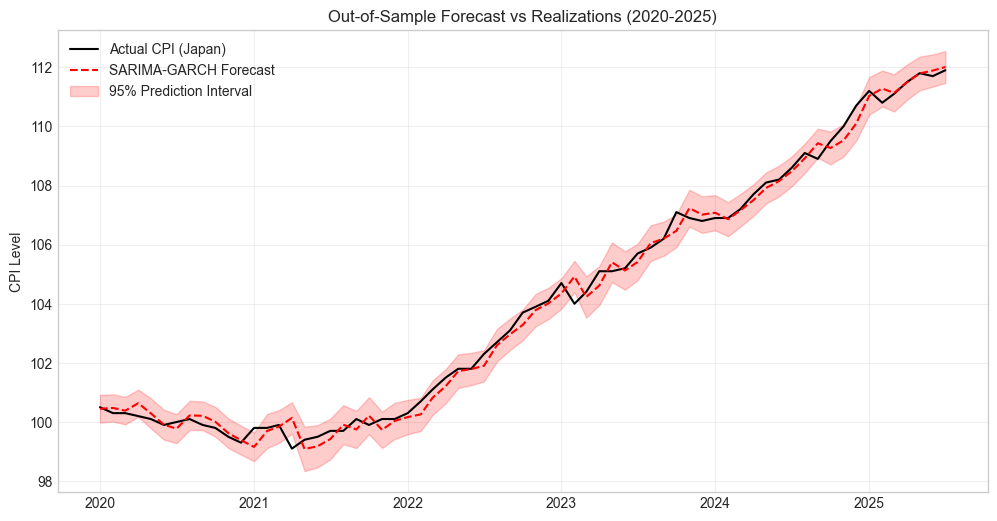

In [543]:
plt.figure(figsize=(12,6))
plt.plot(results_df['Actual_Level'], label='Actual CPI (Japan)', color='black', linewidth=1.5)
plt.plot(results_df['Level_Forecast'], label='SARIMA-GARCH Forecast', color='red', linestyle='--')

plt.fill_between(
    results_df.index,
    results_df['Lower_95'],
    results_df['Upper_95'],
    color='red',
    alpha=0.2,
    label='95% Prediction Interval'
)

plt.title('Out-of-Sample Forecast vs Realizations (2020-2025)')
plt.ylabel('CPI Level')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The 1-step-ahead SARIMA(1,1,1)(0,1,1,12) + GARCH(1,1) model produces highly accurate out-of-sample forecasts for Japanese CPI from 2020 to 2025. The point forecasts closely track actual CPI levels, with minimal deviations.  

The 95% GARCH-based prediction intervals effectively capture most variations in volatility, demonstrating that the model not only predicts the mean accurately but also provides reliable measures of forecast uncertainty. Indeed, we only have 2 points outside the band (begining of 2021 and 2023)

# Exercise 2 :

In [544]:
ticker = "SI=F" 
df = yf.download(ticker, start="2020-01-01", end="2025-09-30")
df = df['Close'].dropna()

def get_returns(series, freq='D'):
    resampled = series.resample(freq).last().ffill()
    return np.log(resampled / resampled.shift(1)).dropna()

ret_daily = get_returns(df, 'D')
ret_monthly = get_returns(df, 'ME')
ret_quarterly = get_returns(df, 'QE')


[*********************100%***********************]  1 of 1 completed


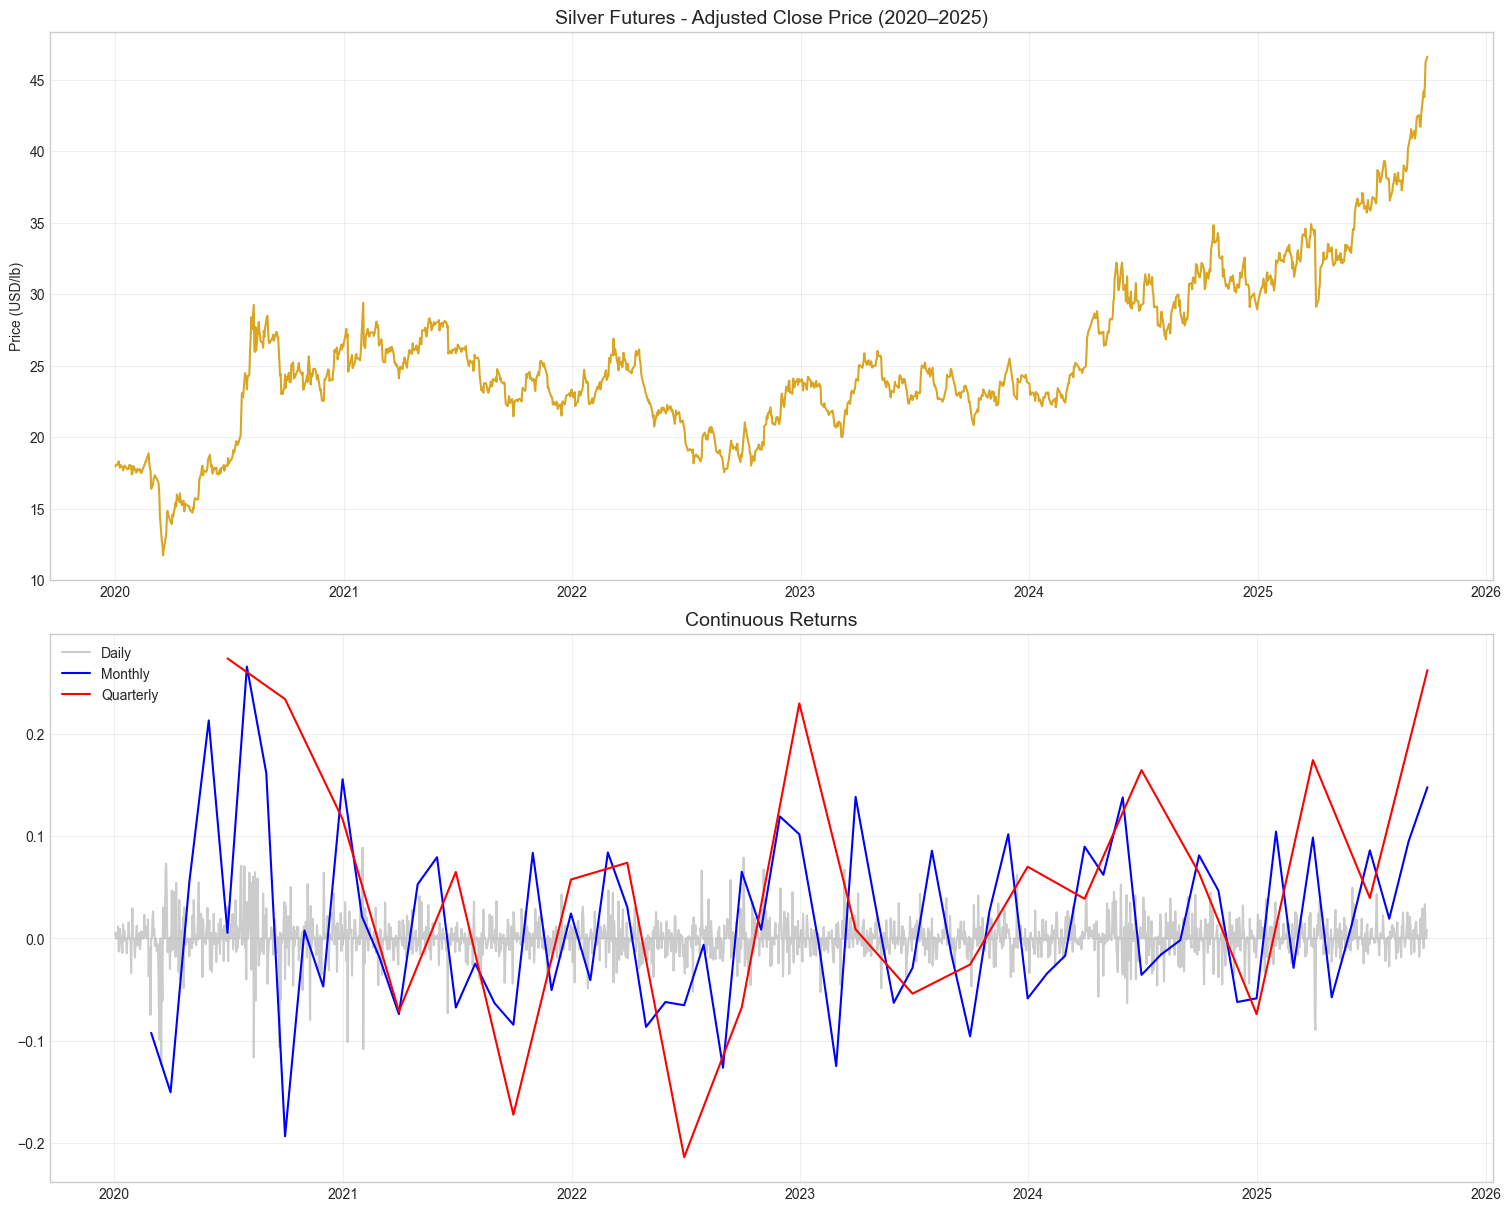

In [545]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 12),
    constrained_layout=True
)

ax[0].plot(df, color='goldenrod', linewidth=1.5)
ax[0].set_title('Silver Futures - Adjusted Close Price (2020–2025)', fontsize=14)
ax[0].set_ylabel('Price (USD/lb)')
ax[0].grid(True, alpha=0.3)

ax[1].plot(ret_daily.index, ret_daily, label='Daily', alpha=0.4, color='gray')
ax[1].plot(ret_monthly.index, ret_monthly, label='Monthly', linewidth=1.5, color='blue')
ax[1].plot(ret_quarterly.index, ret_quarterly, label='Quarterly', linewidth=1.5, color='red')

ax[1].set_title('Continuous Returns', fontsize=14)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.show()


2. Identifying adequate SARIMA-GARCH

Monthly Returns

In [546]:
run_adf_test(ret_daily, "Copper Daily Return")

--- ADF Test Results for: Copper Daily Return ---

Form: n
ADF Statistic: -47.0246
p-value: 0.0000
Critical Values:
	1%: -2.5668
	5%: -1.9411
	10%: -1.6167

Form: c
ADF Statistic: -47.0462
p-value: 0.0000
Critical Values:
	1%: -3.4335
	5%: -2.8629
	10%: -2.5675

Form: ct
ADF Statistic: -47.0460
p-value: 0.0000
Critical Values:
	1%: -3.9631
	5%: -3.4126
	10%: -3.1283

Form: ctt
ADF Statistic: -47.0705
p-value: 0.0000
Critical Values:
	1%: -4.3767
	5%: -3.8352
	10%: -3.5550


The daily return time serie is stationary. ADF test shows that we reject the null hypothesis for each form, meaning the serie is stationary.

In [547]:
lag = 10
results = sm.stats.diagnostic.acorr_ljungbox(ret_daily[1:], lags=lag)
print(f"\nLag: {lag}")
print(f'LjungBox Statistic: {results}')


Lag: 10
LjungBox Statistic:       lb_stat  lb_pvalue
1    1.614081   0.203919
2    3.919578   0.140888
3    4.786875   0.188085
4    5.261538   0.261499
5    5.264813   0.384424
6    7.590432   0.269670
7    9.820636   0.198968
8   11.806475   0.160050
9   12.037605   0.211198
10  14.602122   0.147255


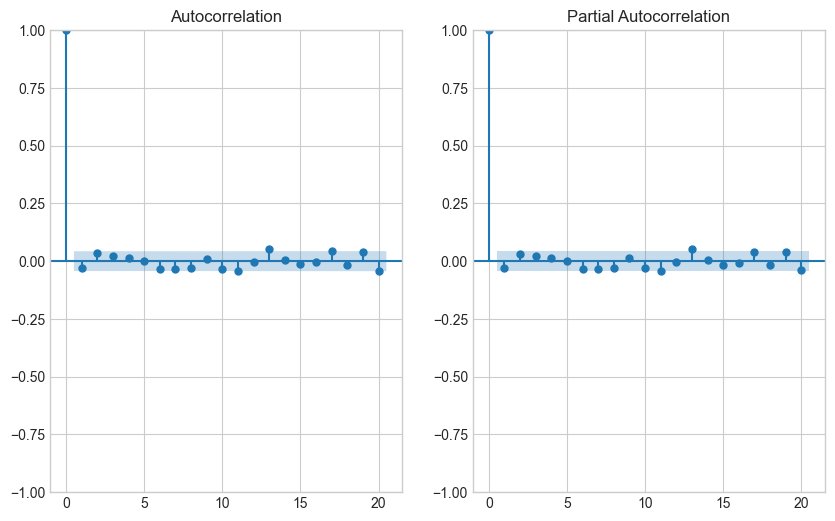

In [548]:
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(ret_daily, lags=20, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(ret_daily, lags=20, ax=ax2, alpha=0.05)

The LjungBox Test is not rejected at 5% on the daily return.  
No autocorrelation to model. 
Graphically, no particular seasonality or obvious rejection on both ACF and PACF. 
Points always touching the confidence interval.  

No need for ARMA model, Box Jenkins approach not justified.

In [549]:
lag = 10
results = sm.stats.diagnostic.acorr_ljungbox(ret_monthly[1:]**2, lags=lag)
print(f"\nLag: {lag}")
print(f'LjungBox Statistic: {results}')


Lag: 10
LjungBox Statistic:       lb_stat  lb_pvalue
1    0.219529   0.639399
2   16.276452   0.000292
3   16.444202   0.000919
4   20.534477   0.000392
5   20.847267   0.000866
6   20.876839   0.001930
7   20.888709   0.003938
8   20.934555   0.007323
9   20.966938   0.012798
10  20.966962   0.021325


LjungBox on squared returns, we reject at 5% for lag 2 to 10.  
There is héteroskedasticity, presence of an ARCH effect.

In [550]:
orders = [(1, 0), (1, 1)]
garch_results = []

for p, q in orders:
    try:
        model = arch_model(residuals, vol='GARCH', p=p, q=q, mean='Zero', dist='normal')
        res = model.fit(disp='off')
        
        garch_results.append({
            'Order (ARCH p, GARCH q)': f'({p},{q})',
            'AIC': res.aic,
            'BIC': res.bic,
            'Log-Likelihood': res.loglikelihood
        })
    except Exception as e:
        print(f"Erreur pour l'ordre ({p},{q}): {e}")

df_garch = pd.DataFrame(garch_results)
print(df_garch)

  Order (ARCH p, GARCH q)         AIC         BIC  Log-Likelihood
0                   (1,0)  166.394205  175.710227      -81.197103
1                   (1,1)  139.097561  153.071594      -66.548781


GARCH(1,1) model performs better as lower AIC, BIC.

Finally, we will use GARCH(1,1) to model the daily return, with no mean equation.

Monthly Returns

In [551]:
run_adf_test(ret_monthly, "Silver Monthly Return")

--- ADF Test Results for: Silver Monthly Return ---

Form: n
ADF Statistic: -7.6513
p-value: 0.0000
Critical Values:
	1%: -2.5999
	5%: -1.9457
	10%: -1.6134

Form: c
ADF Statistic: -7.8250
p-value: 0.0000
Critical Values:
	1%: -3.5320
	5%: -2.9058
	10%: -2.5904

Form: ct
ADF Statistic: -7.7947
p-value: 0.0000
Critical Values:
	1%: -4.1007
	5%: -3.4782
	10%: -3.1666

Form: ctt
ADF Statistic: -8.0852
p-value: 0.0000
Critical Values:
	1%: -4.5532
	5%: -3.9237
	10%: -3.6093


In [552]:
lag = 10
results = sm.stats.diagnostic.acorr_ljungbox(ret_monthly, lags=lag)
print(f"\nLag: {lag}")
print(f'LjungBox Statistic: {results}')


Lag: 10
LjungBox Statistic:      lb_stat  lb_pvalue
1   0.034539   0.852564
2   1.499271   0.472539
3   1.852357   0.603608
4   1.896966   0.754702
5   1.976383   0.852403
6   1.985348   0.921041
7   1.985753   0.960625
8   2.016336   0.980507
9   2.018910   0.991165
10  2.452915   0.991544


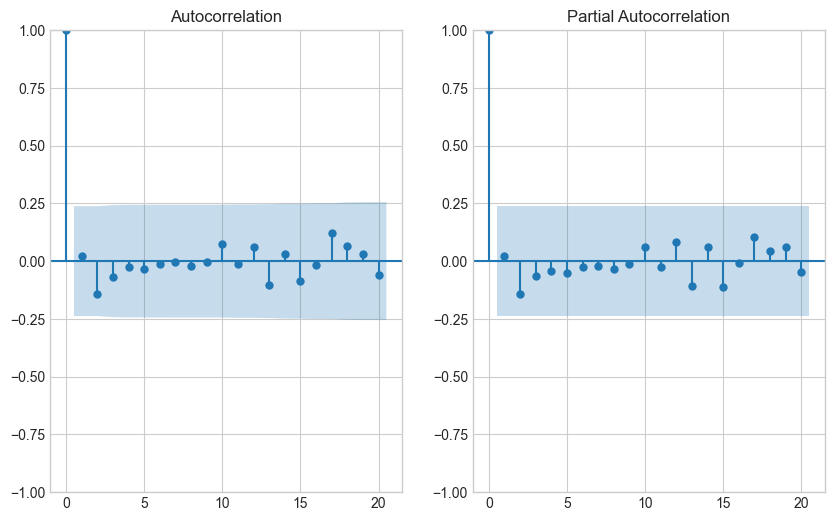

In [553]:
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(ret_monthly, lags=20, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(ret_monthly, lags=20, ax=ax2, alpha=0.05)

The LjungBox Test performed on the monthly returns shows that we don't reject the null at 5% for any lag.  
Additionnally, ACF, PACF are the one of a white noise.    
It means that we don't have autocorrelation to model. Using an ARMA model is not justified here.

In [554]:
lag = 10
results = sm.stats.diagnostic.acorr_ljungbox(ret_monthly[1:]**2, lags=lag)
print(f"\nLag: {lag}")
print(f'LjungBox Statistic: {results}')


Lag: 10
LjungBox Statistic:       lb_stat  lb_pvalue
1    0.219529   0.639399
2   16.276452   0.000292
3   16.444202   0.000919
4   20.534477   0.000392
5   20.847267   0.000866
6   20.876839   0.001930
7   20.888709   0.003938
8   20.934555   0.007323
9   20.966938   0.012798
10  20.966962   0.021325


We reject strongly as of lag 2. There is strong conditional heteroskedasticity.

In [555]:
orders = [(1, 0), (1, 1)]
garch_results = []

for p, q in orders:
    try:
        model = arch_model(residuals, vol='GARCH', p=p, q=q, mean='Zero', dist='normal')
        res = model.fit(disp='off')
        
        garch_results.append({
            'Order (ARCH p, GARCH q)': f'({p},{q})',
            'AIC': res.aic,
            'BIC': res.bic,
            'Log-Likelihood': res.loglikelihood
        })
    except Exception as e:
        print(f"Erreur pour l'ordre ({p},{q}): {e}")

df_garch = pd.DataFrame(garch_results)
print(df_garch)

  Order (ARCH p, GARCH q)         AIC         BIC  Log-Likelihood
0                   (1,0)  166.394205  175.710227      -81.197103
1                   (1,1)  139.097561  153.071594      -66.548781


Same conclusion as in the previous case with daily returns, here we select the GARCH(1,1) with lower AIC, BIC.  

We will only use model conditional variance using GARCH(1,1) on our monthly returns, no mean equation required.

Quarterly Returns

In [556]:
run_adf_test(ret_quarterly, "Silver Quarterly Return")

--- ADF Test Results for: Silver Quarterly Return ---

Form: n
ADF Statistic: -3.7815
p-value: 0.0002
Critical Values:
	1%: -2.6804
	5%: -1.9580
	10%: -1.6076

Form: c
ADF Statistic: 0.4561
p-value: 0.9835
Critical Values:
	1%: -4.1378
	5%: -3.1550
	10%: -2.7145

Form: ct
ADF Statistic: -4.6029
p-value: 0.0010
Critical Values:
	1%: -4.7994
	5%: -3.7867
	10%: -3.3399

Form: ctt
ADF Statistic: -2.3193
p-value: 0.6695
Critical Values:
	1%: -5.3169
	5%: -4.2792
	10%: -3.8182


The first case with no constant is rejected meaning the serie is stationary. Additionally, when adding the constant we do'nt reject, constant and trend we reject, contant and quadratic trend we don't reject.  
Overall, we can say that it seems there is a deterministic influence on the quaterly returns, maybe because we don't have a lot of data also. But as the first form without constant is rejected, we can say that the serie is stationary.

In [557]:
lag = 10
results = sm.stats.diagnostic.acorr_ljungbox(ret_quarterly, lags=lag)
print(f"\nLag: {lag}")
print(f'LjungBox Statistic: {results}')


Lag: 10
LjungBox Statistic:      lb_stat  lb_pvalue
1   0.122782   0.726036
2   0.283960   0.867639
3   0.333611   0.953588
4   0.353215   0.986125
5   0.382422   0.995800
6   0.599054   0.996416
7   1.482806   0.982899
8   5.380062   0.716289
9   5.567289   0.782322
10  6.213760   0.796996


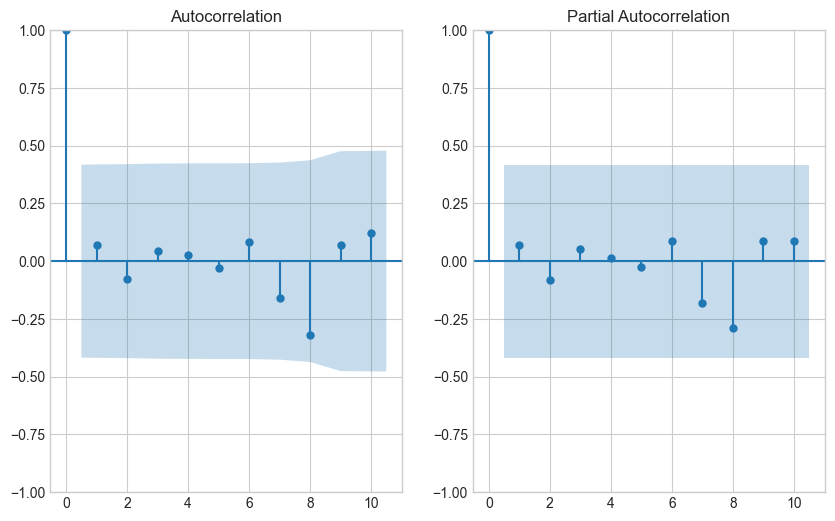

In [558]:
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1,2,1)
fig = sm.graphics.tsa.plot_acf(ret_quarterly, lags=10, ax=ax1, alpha=0.05)
ax2 = fig.add_subplot(1,2,2)
fig = sm.graphics.tsa.plot_pacf(ret_quarterly, lags=10, ax=ax2, alpha=0.05)

Same conclusion as before, no autocorrelation to model. ACF, PACF of a White Noise.  
ARMA framework not pertinent.

In [559]:
lag = 10
results = sm.stats.diagnostic.acorr_ljungbox(ret_quarterly**2, lags=lag)
print(f"\nLag: {lag}")
print(f'LjungBox Statistic: {results}')


Lag: 10
LjungBox Statistic:      lb_stat  lb_pvalue
1   0.000010   0.997461
2   0.295860   0.862492
3   0.539043   0.910234
4   1.297451   0.861808
5   1.457026   0.917975
6   2.034587   0.916490
7   2.257102   0.944252
8   2.373214   0.967381
9   2.516341   0.980441
10  2.570815   0.989803


Here we don't reject at 5% for any lag. No evidence of ARCH effect.  
No need to model conditional heteroskedasticity.

This serie of quaterly return will be used like this, not particular mean or variance equation. It is considered a white noise.

3) Markov Switching 

In the 3 previous models, we didn't find any ARMA trend. Additionally, the GARCH effect is taken into account in statsmodels by specifying "switching_variance=True".  
As a consequence, we will use our initial returns not modified as there are no trend argument to fill (corresponding to AR order)

In [604]:
cutoff = '2022-12-31'

# 1. Quarterly 
mod_q = MarkovRegression(ret_quarterly[:cutoff], k_regimes=2, order=0, switching_variance=True)
res_q = mod_q.fit()

# 2. Monthly 
mod_m = MarkovRegression(ret_monthly[:cutoff], k_regimes=2, order=0, switching_variance=True)
res_m = mod_m.fit()

# 3. Daily
mod_d = MarkovRegression(ret_daily[:cutoff], k_regimes=2, order=0, switching_variance=True)
res_d = mod_d.fit()


In [605]:
print(res_q.summary())

                        Markov Switching Model Results                        
Dep. Variable:                   SI=F   No. Observations:                   11
Model:               MarkovRegression   Log Likelihood                   6.697
Date:                Tue, 23 Dec 2025   AIC                             -1.394
Time:                        00:54:46   BIC                              0.994
Sample:                    06-30-2020   HQIC                            -2.899
                         - 12-31-2022                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1936      0.015    -12.582      0.000      -0.224      -0.163
sigma2         0.0004      0.000      0.977      0.3

The Markov Switching model for quarterly returns identifies two distinct market regimes, though the small sample size (n=11) impacts statistical robustness.

Regime 0 (Contraction) is characterized by significant negative returns (-19.36%) and very low volatility. This represents sharp, brief market corrections.

Regime 1 (Expansion): Characterized by positive returns (+9.86%) but with substantially higher volatility (0.0147). This represents a "high-risk, high-reward" phase.

However, the model indicates that Regime 0 is highly unstable (P0->0)≈NaN≈0, suggesting that negative shocks are quickly mean-reverting.
The NaN values in the transition probabilities occur as a common numerical issue because the sample size is insufficient to estimate regime persistence accurately. (only 11 quarterly observations here).  
As a conclusion, the model is not statistically reliable for inference or long-term forecasting.

In [606]:
print(res_m.summary())

                        Markov Switching Model Results                        
Dep. Variable:                   SI=F   No. Observations:                   35
Model:               MarkovRegression   Log Likelihood                  33.279
Date:                Tue, 23 Dec 2025   AIC                            -54.557
Time:                        00:54:49   BIC                            -45.225
Sample:                    02-29-2020   HQIC                           -51.336
                         - 12-31-2022                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0710      0.008     -9.245      0.000      -0.086      -0.056
sigma2         0.0001      0.000      1.046      0.2

The Monthly model (n=35) is significantly more robust than the Quarterly version, with all parameters successfully converging. The high statistical significance of the Regime 0 mean (p<0.001) and the Regime 1 variance (p<0.001) confirms that the data is best described by two distinct market states.

Regime 0, Bearish: Defined by a sharp average monthly decline of -7.10%. Surprisingly, this regime has the lowest volatility 0.0001, suggesting that downward movements in this commodity are consistent and trending rather than erratic.

Regime 1 Bullish: Defined by a positive average growth of +2.26%. However, volatility here is 100 times higher than in the bearish regime, indicating that growth periods are plagued by large, unpredictable price swings.


Transition:   
Regime 1 is highly "sticky" with an 87.9% probability of remaining in that state month-to-month.  
Regime 0 is transient with only a 34.16% chance of staying in a crash state, suggesting the market typically rebounds or shifts back to volatile growth quickly

In [607]:
print(res_d.summary())

                        Markov Switching Model Results                        
Dep. Variable:                   SI=F   No. Observations:                 1094
Model:               MarkovRegression   Log Likelihood                6022.183
Date:                Tue, 23 Dec 2025   AIC                         -12032.366
Time:                        00:54:52   BIC                         -12002.380
Sample:                    01-03-2020   HQIC                        -12021.019
                         - 12-31-2022                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.609e-08   2.67e-09    -17.273      0.000   -5.13e-08   -4.09e-08
sigma2      1.121e-15        nan        nan        n

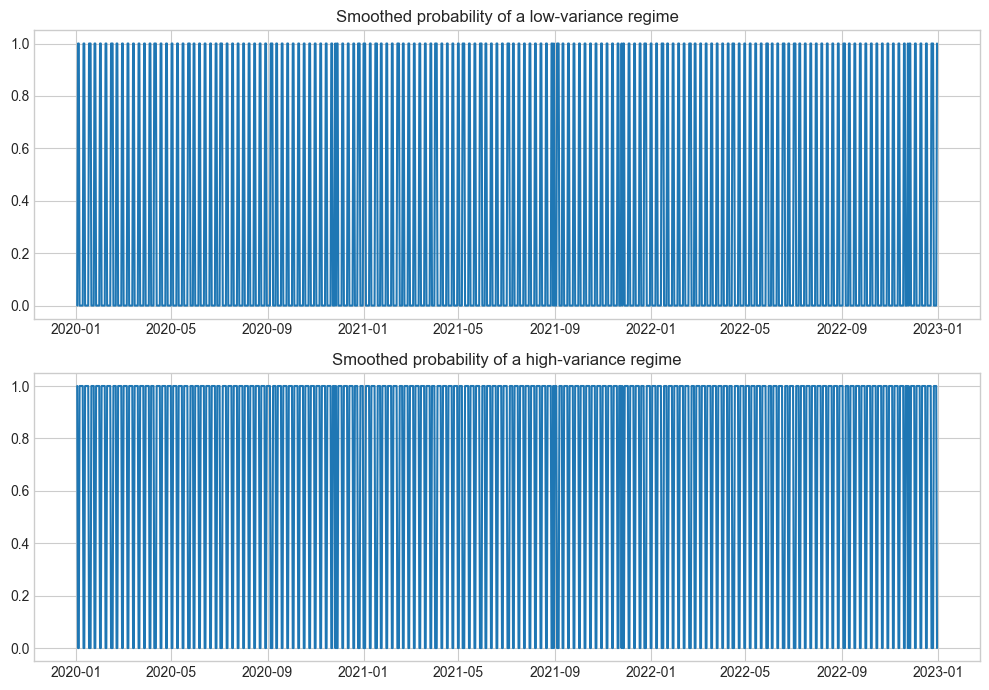

In [608]:
fig, axes = plt.subplots(2, figsize=(10,7))
ax = axes[0]
ax.plot(res_d.smoothed_marginal_probabilities[0])
ax.set(title='Smoothed probability of a low-variance regime')
ax = axes[1]
ax.plot(res_d.smoothed_marginal_probabilities[1])
ax.set(title='Smoothed probability of a high-variance regime')
fig.tight_layout()

1. Robustness and Statistical Significance

The daily model (n=1094) is the most statistically powerful of the three versions, with nearly every parameter achieving extreme significance (p<0.001).

Regime 0 (Flat Market): The mean return (const) is effectively zero at −4.609×10 
−8 (p=0.000), indicating a state where the commodity experiences virtually no price movement.

Regime 1 (The Active Market): Both the mean return (0.0230) and variance (0.0007) are highly significant (p=0.000), confirming that growth periods are fundamentally linked to increased trading activity and volatility.

2. The "Stagnation" vs. "High-Energy Growth" Contrast

The daily parameters reveal a market that spends its time between complete dormancy and active price appreciation:

Regime 0 (Dormancy): The volatility (sigma2) is exceptionally low (1.121×10 
−15
 ), representing "flat-line" days where the market is essentially asleep.

Regime 1 (Activity): The variance is exponentially higher than in Regime 0, showing that daily gains of +2.3% are accompanied by significant price swings. This aligns with the "volatility clustering" often captured by GARCH models.

3. Regime Persistence and Fluid Dynamics

The daily transition parameters show a more "fluid" market than the monthly scale, with frequent shifts between states:

Growth Persistence (P 
11
​	
 ): Since p[1→0] is 0.3705, the probability of staying in the active growth regime (p[1→1]) is approximately 62.95%. This suggests that active trading "streaks" usually last a few days before cooling off.

Flat-Market Stability (P 
00
​	
 ): The probability of staying in the stagnant state (p[0→0]) is 56.42%. This indicates that "quiet" periods in the market are slightly less persistent than active ones, with a high chance of pivoting back into an active state

In [ ]:
def forecast_returns(results, steps):
    """Forecast returns h-steps ahead"""
    P = np.array(results.regime_transition).squeeze().T
    current_probs = results.filtered_marginal_probabilities.iloc[-1].values
    
    # Get regime means
    means = np.array([results.params[f'const[{i}]'] for i in range(results.k_regimes)])
    
    # Forecast returns
    return_forecasts = []
    temp_p = current_probs.copy()
    
    for h in range(1, steps + 1):
        temp_p = temp_p @ P
        # Expected return is weighted average of regime means
        expected_return = np.dot(temp_p, means)
        return_forecasts.append(expected_return)
    
    return np.array(return_forecasts)

# Quarterly return forecasts (3 quarters ahead)
fc_returns_q = forecast_returns(res_q, steps=3)
actual_returns_q = ret_quarterly['2023-01-01':].head(3).values

# Monthly return forecasts (9 months ahead)
fc_returns_m = forecast_returns(res_m, steps=9)
actual_returns_m = ret_monthly['2023-01-01':].head(9).values

print("="*60)
print("RETURN FORECASTS vs ACTUAL REALIZATIONS")
print("="*60)

print(f"\nQuarterly Forecasts (3 quarters ahead from Dec 2022):")
for i in range(3):
    fc_val = float(fc_returns_q[i])
    if i < len(actual_returns_q):
        act_val = float(actual_returns_q[i])
        error = fc_val - act_val
        print(f"  Q{i+1} 2023: Forecast = {fc_val:.6f} ({fc_val*100:.4f}%), "
              f"Actual = {act_val:.6f} ({act_val*100:.4f}%), "
              f"Error = {error:.6f}")
    else:
        print(f"  Q{i+1} 2023: Forecast = {fc_val:.6f} ({fc_val*100:.4f}%)")

print(f"\nMonthly Forecasts (9 months ahead from Dec 2022):")
for i in range(9):
    fc_val = float(fc_returns_m[i])
    if i < len(actual_returns_m):
        act_val = float(actual_returns_m[i])
        error = fc_val - act_val
        print(f"  Month {i+1} 2023: Forecast = {fc_val:.6f} ({fc_val*100:.4f}%), "
              f"Actual = {act_val:.6f} ({act_val*100:.4f}%), "
              f"Error = {error:.6f}")
    else:
        print(f"  Month {i+1} 2023: Forecast = {fc_val:.6f} ({fc_val*100:.4f}%)")

# Compute forecast accuracy metrics
if len(actual_returns_q) == 3:
    mse_q = np.mean((fc_returns_q[:3] - actual_returns_q)**2)
    mae_q = np.mean(np.abs(fc_returns_q[:3] - actual_returns_q))
    print(f"\nQuarterly Forecast Accuracy:")
    print(f"  MSE: {mse_q:.8f}")
    print(f"  MAE: {mae_q:.8f}")

if len(actual_returns_m) == 9:
    mse_m = np.mean((fc_returns_m[:9] - actual_returns_m)**2)
    mae_m = np.mean(np.abs(fc_returns_m[:9] - actual_returns_m))
    print(f"\nMonthly Forecast Accuracy:")
    print(f"  MSE: {mse_m:.8f}")
    print(f"  MAE: {mae_m:.8f}")


RETURN FORECASTS vs ACTUAL REALIZATIONS

Quarterly Forecasts (3 quarters ahead from Dec 2022):
  Q1 2023: Forecast = 0.034646 (3.4646%), Actual = 0.008928 (0.8928%), Error = 0.025717
  Q2 2023: Forecast = 0.048642 (4.8642%), Actual = -0.054016 (-5.4016%), Error = 0.102658
  Q3 2023: Forecast = 0.045578 (4.5578%), Actual = -0.025486 (-2.5486%), Error = 0.071065

Monthly Forecasts (9 months ahead from Dec 2022):
  Month 1 2023: Forecast = 0.011309 (1.1309%), Actual = -0.004789 (-0.4789%), Error = 0.016098
  Month 2 2023: Forecast = 0.008810 (0.8810%), Actual = -0.124835 (-12.4835%), Error = 0.133645
  Month 3 2023: Forecast = 0.008259 (0.8259%), Actual = 0.138552 (13.8552%), Error = -0.130293
  Month 4 2023: Forecast = 0.008138 (0.8138%), Actual = 0.037620 (3.7620%), Error = -0.029483
  Month 5 2023: Forecast = 0.008111 (0.8111%), Actual = -0.062942 (-6.2942%), Error = 0.071053
  Month 6 2023: Forecast = 0.008105 (0.8105%), Actual = -0.028694 (-2.8694%), Error = 0.036799
  Month 7 2023: 

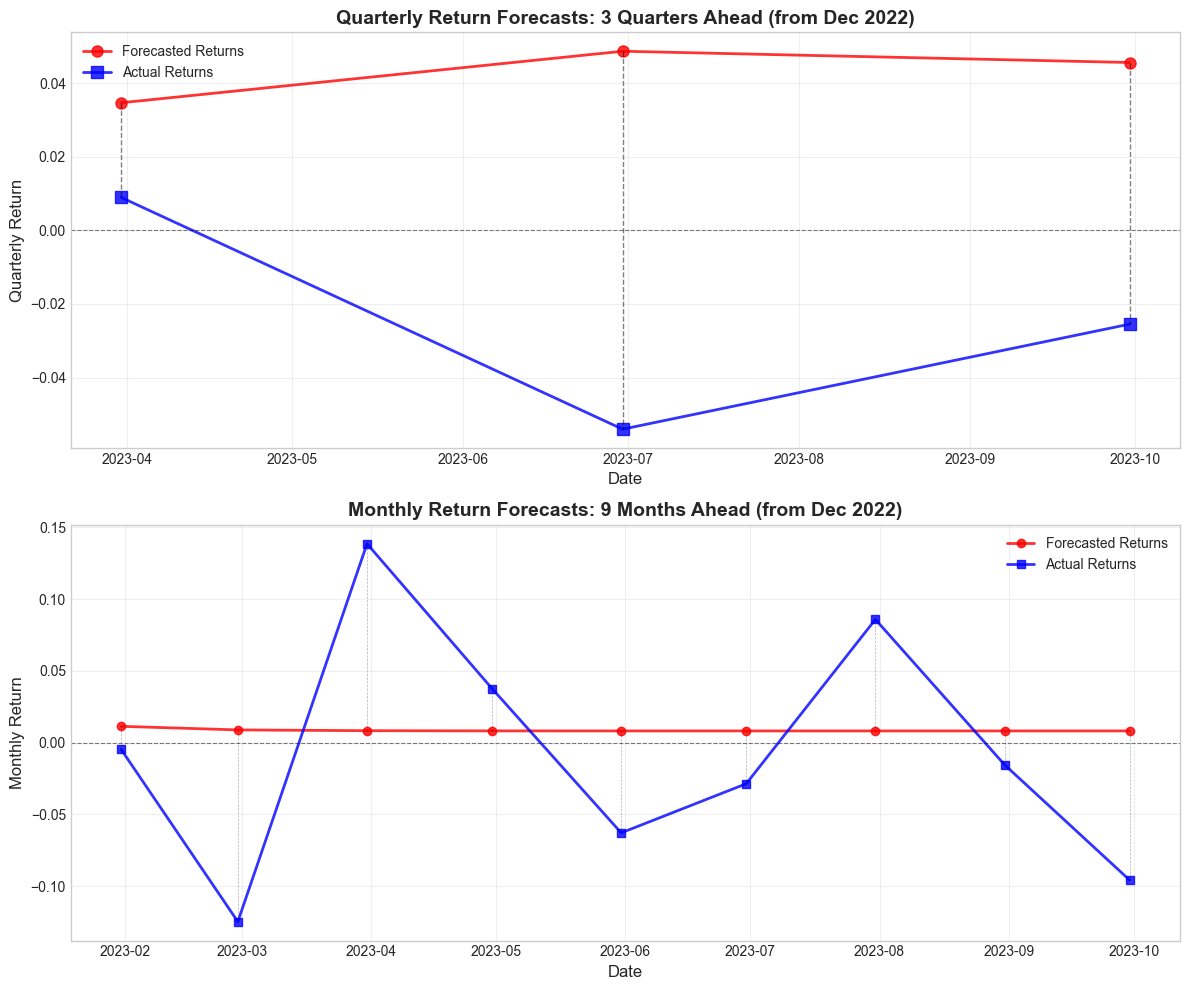

In [667]:
# Visualize Quarterly and Monthly Return Forecasts vs Actuals
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Quarterly forecasts
ax1 = axes[0]
forecast_dates_q = pd.date_range(start='2023-01-01', periods=3, freq='QE')
fc_returns_q_float = [float(x) for x in fc_returns_q]
if len(actual_returns_q) == 3:
    actual_returns_q_float = [float(x) for x in actual_returns_q]
    ax1.plot(forecast_dates_q, fc_returns_q_float, 'o-', color='red', linewidth=2, 
             markersize=8, label='Forecasted Returns', alpha=0.8)
    ax1.plot(forecast_dates_q, actual_returns_q_float, 's-', color='blue', linewidth=2, 
             markersize=8, label='Actual Returns', alpha=0.8)
    ax1.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    for i, (fc, act) in enumerate(zip(fc_returns_q_float, actual_returns_q_float)):
        ax1.plot([forecast_dates_q[i], forecast_dates_q[i]], [fc, act], 
                'k--', linewidth=1, alpha=0.5)
else:
    ax1.plot(forecast_dates_q, fc_returns_q_float, 'o-', color='red', linewidth=2, 
             markersize=8, label='Forecasted Returns', alpha=0.8)
ax1.set_title('Quarterly Return Forecasts: 3 Quarters Ahead (from Dec 2022)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Quarterly Return', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Monthly forecasts
ax2 = axes[1]
forecast_dates_m = pd.date_range(start='2023-01-01', periods=9, freq='ME')
fc_returns_m_float = [float(x) for x in fc_returns_m]
if len(actual_returns_m) == 9:
    actual_returns_m_float = [float(x) for x in actual_returns_m]
    ax2.plot(forecast_dates_m, fc_returns_m_float, 'o-', color='red', linewidth=2, 
             markersize=6, label='Forecasted Returns', alpha=0.8)
    ax2.plot(forecast_dates_m, actual_returns_m_float, 's-', color='blue', linewidth=2, 
             markersize=6, label='Actual Returns', alpha=0.8)
    ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    for i, (fc, act) in enumerate(zip(fc_returns_m_float, actual_returns_m_float)):
        ax2.plot([forecast_dates_m[i], forecast_dates_m[i]], [fc, act], 
                'k--', linewidth=0.5, alpha=0.3)
else:
    ax2.plot(forecast_dates_m, fc_returns_m_float, 'o-', color='red', linewidth=2, 
             markersize=6, label='Forecasted Returns', alpha=0.8)
ax2.set_title('Monthly Return Forecasts: 9 Months Ahead (from Dec 2022)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Monthly Return', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


We can see that forecasts converge to unconditional mean as horizon increases.
This is expected behavior for return forecasts in efficient markets. Additionally, as we didn't find any arma process, we could expect this immediate convergence.

Daily

In [ ]:
oos_dates = ret_daily[cutoff:].index
realized_probs_list = [] 
all_step_forecasts = []
oos_dates_successful = []

for i in range(len(oos_dates)):
    current_end_date = oos_dates[i]
    train_slice = ret_daily[:current_end_date]
    
    try:
        temp_mod = MarkovRegression(train_slice, k_regimes=2, order=0, switching_variance=True)
        temp_res = temp_mod.fit(search_reps=5, disp=False)
        
        P = np.array(temp_res.regime_transition).squeeze().T
        current_probs = temp_res.filtered_marginal_probabilities.iloc[-1].values
        means = np.array([temp_res.params[f'const[{j}]'] for j in range(temp_res.k_regimes)])
        
        realized_probs_list.append(current_probs[1]) 
        
        step_path = []
        temp_p = current_probs
        for h in range(1, 21):
            temp_p = temp_p @ P
            step_path.append(np.dot(temp_p, means))
            
        all_step_forecasts.append(step_path)
        oos_dates_successful.append(current_end_date)
        
    except Exception as e:
        print(f"Skipping {current_end_date.date()} due to error: {e}")
        continue

forecast_df = pd.DataFrame(all_step_forecasts, index=oos_dates_successful)

DAILY RECURSIVE FORECAST EVALUATION
[0.         0.         0.         ... 0.         0.         0.00842375]

1-Step Ahead Forecast Accuracy:
  Number of forecasts: 1004
  MSE: 0.00023719
  MAE: 0.01029185
  RMSE: 0.01540090
  Mean Forecast: -0.00050425
  Mean Actual: 0.00066690

20-Step Ahead Forecast Accuracy:
  Number of forecasts: 985
  MSE: 0.00024020
  MAE: 0.01050663
  RMSE: 0.01549826
  Mean Forecast: -0.00041122
  Mean Actual: 0.00069399


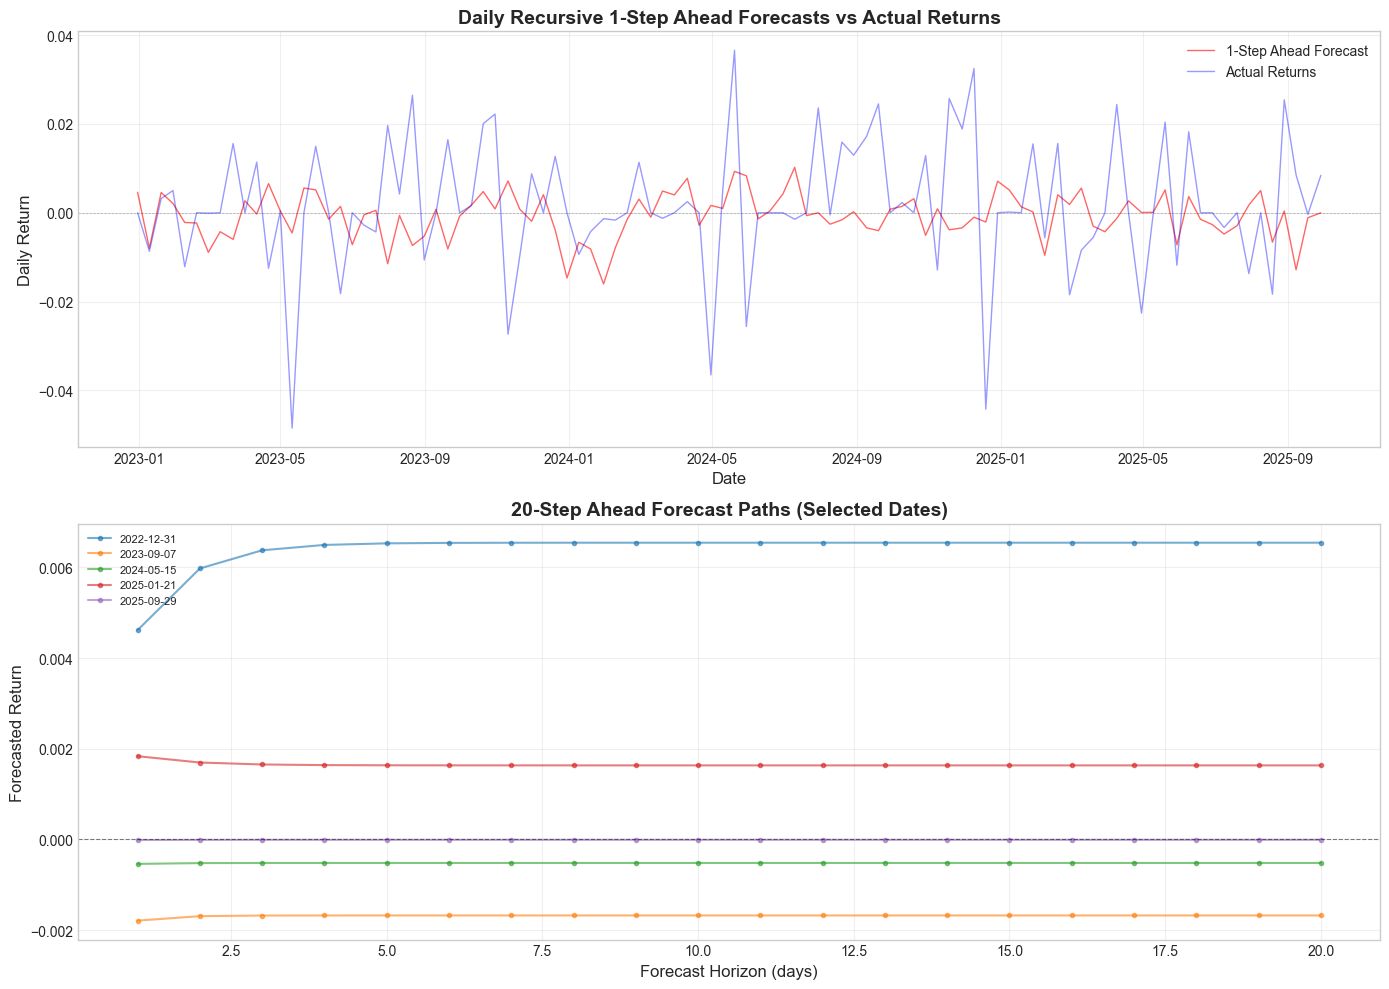

In [668]:
# Evaluate Daily Recursive 20-Step Ahead Forecasts
# forecast_df contains 20-step ahead forecasts for each day in out-of-sample period
# Column 0 = 1-step ahead, Column 19 = 20-step ahead

print("="*60)
print("DAILY RECURSIVE FORECAST EVALUATION")
print("="*60)

# Get actual returns for the forecast period
actual_returns_daily = ret_daily.loc[forecast_df.index]

# Evaluate 1-step ahead forecasts (most relevant)
forecast_1step = forecast_df[0].values.squeeze()
actual_1step = actual_returns_daily.values.squeeze()
print(actual_1step)

# Remove NaN values
valid_mask = ~(np.isnan(forecast_1step) | np.isnan(actual_1step))
forecast_1step_clean = forecast_1step[valid_mask]
actual_1step_clean = actual_1step[valid_mask]

if len(forecast_1step_clean) > 0:
    mse_1step = np.mean((forecast_1step_clean - actual_1step_clean)**2)
    mae_1step = np.mean(np.abs(forecast_1step_clean - actual_1step_clean))
    rmse_1step = np.sqrt(mse_1step)
    
    print(f"\n1-Step Ahead Forecast Accuracy:")
    print(f"  Number of forecasts: {len(forecast_1step_clean)}")
    print(f"  MSE: {mse_1step:.8f}")
    print(f"  MAE: {mae_1step:.8f}")
    print(f"  RMSE: {rmse_1step:.8f}")
    print(f"  Mean Forecast: {np.mean(forecast_1step_clean):.8f}")
    print(f"  Mean Actual: {np.mean(actual_1step_clean):.8f}")

# Evaluate 20-step ahead forecasts
forecast_20step = forecast_df[19].values.squeeze()  # Column 19 = 20-step ahead
actual_20step = actual_returns_daily.values.squeeze()

# For 20-step ahead, we need to align with actuals 20 days ahead
if len(actual_20step) >= 20:
    actual_20step_aligned = actual_20step[19:]  # Start from day 20
    forecast_20step_aligned = forecast_20step[:-19]  # Remove last 19 forecasts
    
    valid_mask_20 = ~(np.isnan(forecast_20step_aligned) | np.isnan(actual_20step_aligned))
    forecast_20step_clean = forecast_20step_aligned[valid_mask_20]
    actual_20step_clean = actual_20step_aligned[valid_mask_20]
    
    if len(forecast_20step_clean) > 0:
        mse_20step = np.mean((forecast_20step_clean - actual_20step_clean)**2)
        mae_20step = np.mean(np.abs(forecast_20step_clean - actual_20step_clean))
        rmse_20step = np.sqrt(mse_20step)
        
        print(f"\n20-Step Ahead Forecast Accuracy:")
        print(f"  Number of forecasts: {len(forecast_20step_clean)}")
        print(f"  MSE: {mse_20step:.8f}")
        print(f"  MAE: {mae_20step:.8f}")
        print(f"  RMSE: {rmse_20step:.8f}")
        print(f"  Mean Forecast: {np.mean(forecast_20step_clean):.8f}")
        print(f"  Mean Actual: {np.mean(actual_20step_clean):.8f}")


fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: 1-step ahead forecasts vs actuals
ax1 = axes[0]
sample_indices = np.linspace(0, len(forecast_df)-1, min(100, len(forecast_df)), dtype=int)
ax1.plot(forecast_df.index[sample_indices], forecast_1step[sample_indices], 
         'r-', linewidth=1, alpha=0.6, label='1-Step Ahead Forecast')
ax1.plot(forecast_df.index[sample_indices], actual_1step[sample_indices], 
         'b-', linewidth=1, alpha=0.4, label='Actual Returns')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.5, alpha=0.3)
ax1.set_title('Daily Recursive 1-Step Ahead Forecasts vs Actual Returns', fontsize=14, fontweight='bold')
ax1.set_ylabel('Daily Return', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Forecast horizon analysis (how forecasts evolve across horizons)
ax2 = axes[1]
selected_dates_idx = np.linspace(0, len(forecast_df)-1, min(5, len(forecast_df)), dtype=int)
for idx in selected_dates_idx:
    forecast_path = forecast_df.iloc[idx].values
    ax2.plot(range(1, 21), forecast_path, 'o-', alpha=0.6, markersize=3, 
             label=f'{forecast_df.index[idx].strftime("%Y-%m-%d")}')

ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_title('20-Step Ahead Forecast Paths (Selected Dates)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Forecast Horizon (days)', fontsize=12)
ax2.set_ylabel('Forecasted Return', fontsize=12)
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The recursive forecasting approach re-estimates the model each day with expanding window, then produces 20-step ahead forecasts as required. We can identify the quick convergence behavior to the unconditional mean we spotted before for monthly and quarterly returns.

Additionally, comparing the 1-step ahead forecast accuracy vs 20-step ahead in terms of RMSE, we can say that the 20-Step Ahead Forecast Accuracy is slighly better.

In [ ]:
def compute_unconditional_stats(results, name):
    """Compute unconditional mean and steady-state probabilities"""
    # Get transition matrix
    P = np.array(results.regime_transition).squeeze().T
    
    # Compute steady-state probabilities (eigenvector of P^T with eigenvalue 1)
    eigenvals, eigenvecs = np.linalg.eig(P.T)
    # Find eigenvector corresponding to eigenvalue 1
    idx = np.argmax(np.real(eigenvals))
    steady_state = np.real(eigenvecs[:, idx])
    steady_state = steady_state / steady_state.sum()  
    
    # Regime means
    means = np.array([results.params[f'const[{i}]'] for i in range(results.k_regimes)])
    
    # Unconditional mean
    unconditional_mean = np.dot(steady_state, means)
    
    print(f"\n{'='*60}")
    print(f"{name} - Unconditional Statistics")
    print(f"{'='*60}")
    print(f"\nSteady-State Probabilities:")
    for i in range(results.k_regimes):
        print(f"  Regime {i}: {steady_state[i]:.4f} ({steady_state[i]*100:.2f}%)")
    
    print(f"\nRegime Means:")
    for i in range(results.k_regimes):
        print(f"  Regime {i}: {means[i]:.6f} ({means[i]*100:.4f}% per period)")
    
    print(f"\nUnconditional Mean: {unconditional_mean:.6f} ({unconditional_mean*100:.4f}% per period)")
    print(f"\nTransition Matrix P:")
    print(f"  P[0->0] = {P[0,0]:.4f},  P[0->1] = {P[0,1]:.4f}")
    print(f"  P[1->0] = {P[1,0]:.4f},  P[1->1] = {P[1,1]:.4f}")
    
    return steady_state, unconditional_mean, means, P

print("\n" + "="*60)
print("MARKOV SWITCHING MODEL - UNCONDITIONAL STATISTICS")
print("="*60)

steady_q, uncond_q, means_q, P_q = compute_unconditional_stats(res_q, "Quarterly")
steady_m, uncond_m, means_m, P_m = compute_unconditional_stats(res_m, "Monthly")
steady_d, uncond_d, means_d, P_d = compute_unconditional_stats(res_d, "Daily")



MARKOV SWITCHING MODEL - UNCONDITIONAL STATISTICS

Quarterly - Unconditional Statistics

Steady-State Probabilities:
  Regime 0: 0.1796 (17.96%)
  Regime 1: 0.8204 (82.04%)

Regime Means:
  Regime 0: -0.193577 (-19.3577% per period)
  Regime 1: 0.098593 (9.8593% per period)

Unconditional Mean: 0.046128 (4.6128% per period)

Transition Matrix P:
  P[0->0] = 0.0000,  P[0->1] = 1.0000
  P[1->0] = 0.2189,  P[1->1] = 0.7811

Monthly - Unconditional Statistics

Steady-State Probabilities:
  Regime 0: 0.1553 (15.53%)
  Regime 1: 0.8447 (84.47%)

Regime Means:
  Regime 0: -0.070960 (-7.0960% per period)
  Regime 1: 0.022636 (2.2636% per period)

Unconditional Mean: 0.008103 (0.8103% per period)

Transition Matrix P:
  P[0->0] = 0.3416,  P[0->1] = 0.6584
  P[1->0] = 0.1210,  P[1->1] = 0.8790

Daily - Unconditional Statistics

Steady-State Probabilities:
  Regime 0: 0.4595 (45.95%)
  Regime 1: 0.5405 (54.05%)

Regime Means:
  Regime 0: -0.000000 (-0.0000% per period)
  Regime 1: 0.023005 (2.30

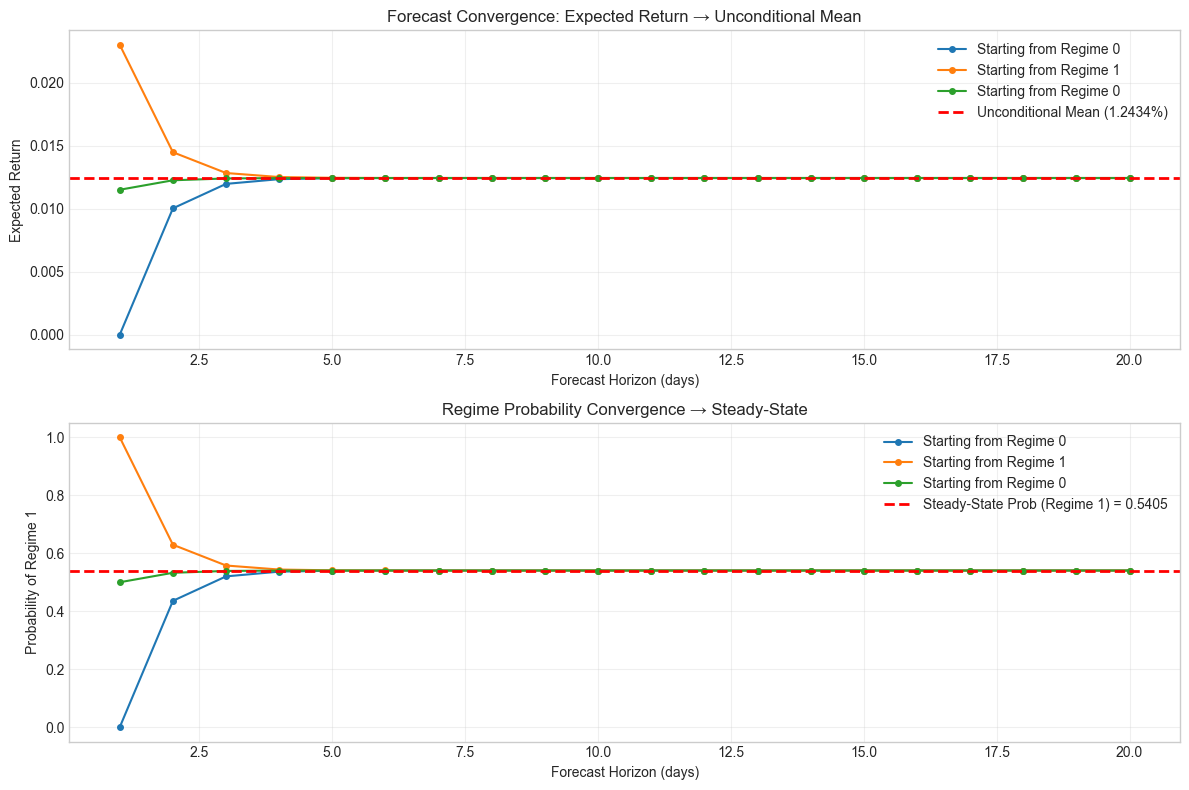


Comment: Regardless of starting regime, forecasts converge to:
  - Expected Return: 0.012434 (1.2434% per day)
  - Regime 1 Probability: 0.5405 (54.05%)

This is why your 1-day ahead forecast graph before looks a bit odd.
Indeed it is converging to the long-run unconditional mean, which is close to zero for returns


In [684]:
P = np.array(res_d.regime_transition).squeeze().T
means = np.array([res_d.params[f'const[{i}]'] for i in range(res_d.k_regimes)])

# Start from different initial regime probabilities
initial_states = [
    np.array([1.0, 0.0]),  # Start in Regime 0
    np.array([0.0, 1.0]),  # Start in Regime 1
    np.array([0.5, 0.5]),  # Start with equal probability
]

# Forecast horizon
horizon = 20

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Forecast convergence for mean returns
ax1 = axes[0]
for i, initial_state in enumerate(initial_states):
    forecast_path = []
    temp_p = initial_state.copy()
    for h in range(horizon):
        forecast_path.append(np.dot(temp_p, means))
        temp_p = temp_p @ P
    
    ax1.plot(range(1, horizon+1), forecast_path, 
             label=f'Starting from Regime {np.argmax(initial_state)}', 
             marker='o', markersize=4)

ax1.axhline(uncond_d, color='red', linestyle='--', linewidth=2, 
            label=f'Unconditional Mean ({uncond_d*100:.4f}%)')
ax1.set_xlabel('Forecast Horizon (days)')
ax1.set_ylabel('Expected Return')
ax1.set_title('Forecast Convergence: Expected Return → Unconditional Mean')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Regime probability convergence
ax2 = axes[1]
for i, initial_state in enumerate(initial_states):
    prob_path = []
    temp_p = initial_state.copy()
    for h in range(horizon):
        prob_path.append(temp_p[1])  # Probability of Regime 1
        temp_p = temp_p @ P
    
    ax2.plot(range(1, horizon+1), prob_path, 
             label=f'Starting from Regime {np.argmax(initial_state)}', 
             marker='o', markersize=4)

ax2.axhline(steady_d[1], color='red', linestyle='--', linewidth=2, 
            label=f'Steady-State Prob (Regime 1) = {steady_d[1]:.4f}')
ax2.set_xlabel('Forecast Horizon (days)')
ax2.set_ylabel('Probability of Regime 1')
ax2.set_title('Regime Probability Convergence → Steady-State')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print(f"\nComment: Regardless of starting regime, forecasts converge to:")
print(f"  - Expected Return: {uncond_d:.6f} ({uncond_d*100:.4f}% per day)")
print(f"  - Regime 1 Probability: {steady_d[1]:.4f} ({steady_d[1]*100:.2f}%)")
print(f"\nThis is why your 1-day ahead forecast graph before looks a bit odd.")
print(f"Indeed it is converging to the long-run unconditional mean, which is close to zero for returns")


The previous results show that returns are unpredictable in the mean, so the model's value lies in volatility/regime identification rather than return prediction. (forecasts converging to unconditional mean) 

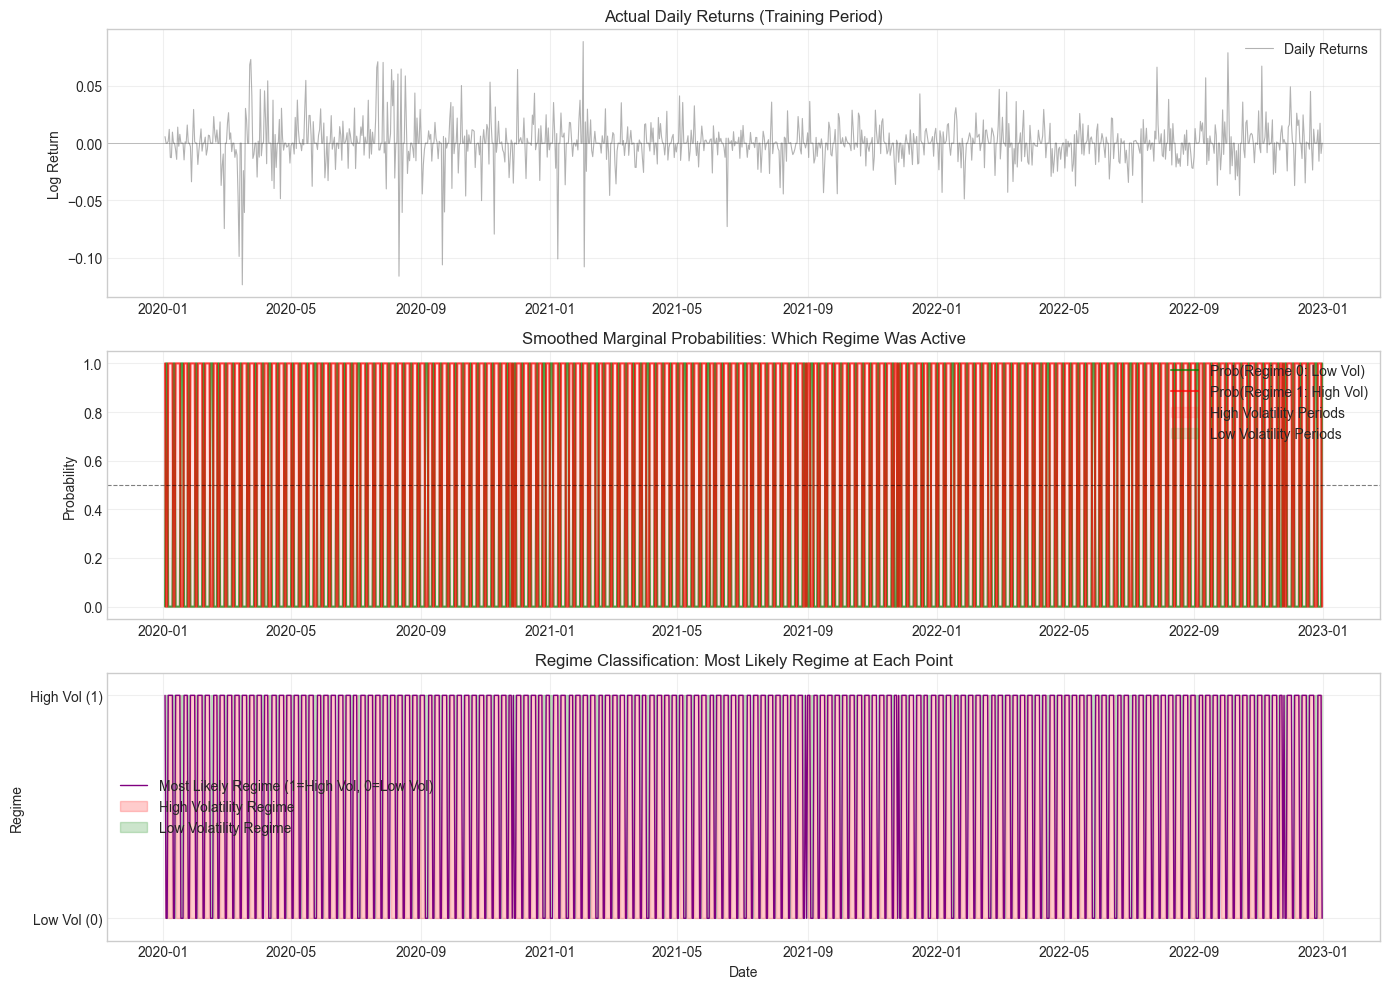


REGIME SUMMARY STATISTICS

Time Spent in Each Regime:
  Regime 0 (Low Vol):  341 days (31.17%)
  Regime 1 (High Vol): 753 days (68.83%)

Average Returns by Regime:
  Regime 0 (Low Vol):  Mean = 0.000000, Std = 0.000000
  Regime 1 (High Vol): Mean = 0.000377, Std = 0.023425


In [672]:
# Enhanced visualization: Smoothed probabilities with actual returns
# This helps interpret which regime the market was in at each point

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Actual returns
ax1 = axes[0]
ax1.plot(ret_daily[:cutoff].index, ret_daily[:cutoff], 
         color='gray', alpha=0.6, linewidth=0.8, label='Daily Returns')
ax1.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax1.set_ylabel('Log Return')
ax1.set_title('Actual Daily Returns (Training Period)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Smoothed probabilities
ax2 = axes[1]
most_likely_regime = (res_d.smoothed_marginal_probabilities[1] > 0.5).astype(int)
most_likely_regime_arr = most_likely_regime.values if isinstance(most_likely_regime, pd.Series) else np.array(most_likely_regime)

ax2.plot(ret_daily[:cutoff].index, res_d.smoothed_marginal_probabilities[0], 
         color='green', linewidth=1.5, label='Prob(Regime 0: Low Vol)', alpha=0.7)
ax2.plot(ret_daily[:cutoff].index, res_d.smoothed_marginal_probabilities[1], 
         color='red', linewidth=1.5, label='Prob(Regime 1: High Vol)', alpha=0.7)
ax2.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.fill_between(ret_daily[:cutoff].index, 0, 1, 
                  where=(most_likely_regime_arr == 1),
                  color='red', alpha=0.1, label='High Volatility Periods')
ax2.fill_between(ret_daily[:cutoff].index, 0, 1, 
                  where=(most_likely_regime_arr == 0),
                  color='green', alpha=0.1, label='Low Volatility Periods')
ax2.set_ylabel('Probability')
ax2.set_title('Smoothed Marginal Probabilities: Which Regime Was Active')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

# Plot 3: Regime classification (most likely regime at each point)
ax3 = axes[2]
ax3.plot(ret_daily[:cutoff].index, most_likely_regime_arr, 
         color='purple', linewidth=1, label='Most Likely Regime (1=High Vol, 0=Low Vol)')
ax3.fill_between(ret_daily[:cutoff].index, 0, 1, 
                  where=(most_likely_regime_arr == 1),
                  color='red', alpha=0.2, label='High Volatility Regime')
ax3.fill_between(ret_daily[:cutoff].index, 0, 1, 
                  where=(most_likely_regime_arr == 0),
                  color='green', alpha=0.2, label='Low Volatility Regime')
ax3.set_ylabel('Regime')
ax3.set_xlabel('Date')
ax3.set_title('Regime Classification: Most Likely Regime at Each Point')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-0.1, 1.1)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Low Vol (0)', 'High Vol (1)'])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("REGIME SUMMARY STATISTICS")
print("="*60)

regime_0_count = int((most_likely_regime_arr == 0).sum())
regime_1_count = int((most_likely_regime_arr == 1).sum())
total_count = len(most_likely_regime_arr)
regime_0_pct = float(regime_0_count / total_count * 100)
regime_1_pct = float(regime_1_count / total_count * 100)

print(f"\nTime Spent in Each Regime:")
print(f"  Regime 0 (Low Vol):  {regime_0_count} days ({regime_0_pct:.2f}%)")
print(f"  Regime 1 (High Vol): {regime_1_count} days ({regime_1_pct:.2f}%)")

print(f"\nAverage Returns by Regime:")
regime_0_returns = ret_daily[:cutoff][most_likely_regime_arr == 0]
regime_1_returns = ret_daily[:cutoff][most_likely_regime_arr == 1]

# Convert to float to ensure scalar values
regime_0_mean = float(regime_0_returns.mean()) if len(regime_0_returns) > 0 else 0.0
regime_0_std = float(regime_0_returns.std()) if len(regime_0_returns) > 0 else 0.0
regime_1_mean = float(regime_1_returns.mean()) if len(regime_1_returns) > 0 else 0.0
regime_1_std = float(regime_1_returns.std()) if len(regime_1_returns) > 0 else 0.0

print(f"  Regime 0 (Low Vol):  Mean = {regime_0_mean:.6f}, Std = {regime_0_std:.6f}")
print(f"  Regime 1 (High Vol): Mean = {regime_1_mean:.6f}, Std = {regime_1_std:.6f}")


When Prob(Regime 1) > 0.5, the market is in a HIGH volatility state"  
When Prob(Regime 0) > 0.5, the market is in a LOW volatility state"

The model identifies periods of market stress characterized by rather high volatility vs calm periods

The strength of Markov switching models lies in changing regimes and volatility forecasts.   
We will look at volatility forecast base on same rolling window we used before for returns.  
To do so, we will use forecast regime probability.

VOLATILITY FORECAST EVALUATION

1-Day Ahead Volatility Forecast (Annualized): 0.2686
Last 20-Day Realized Volatility (Annualized): 0.2719

Regime-Specific Volatilities (Annualized):
  Regime 0: 0.0000
  Regime 1: 0.4069


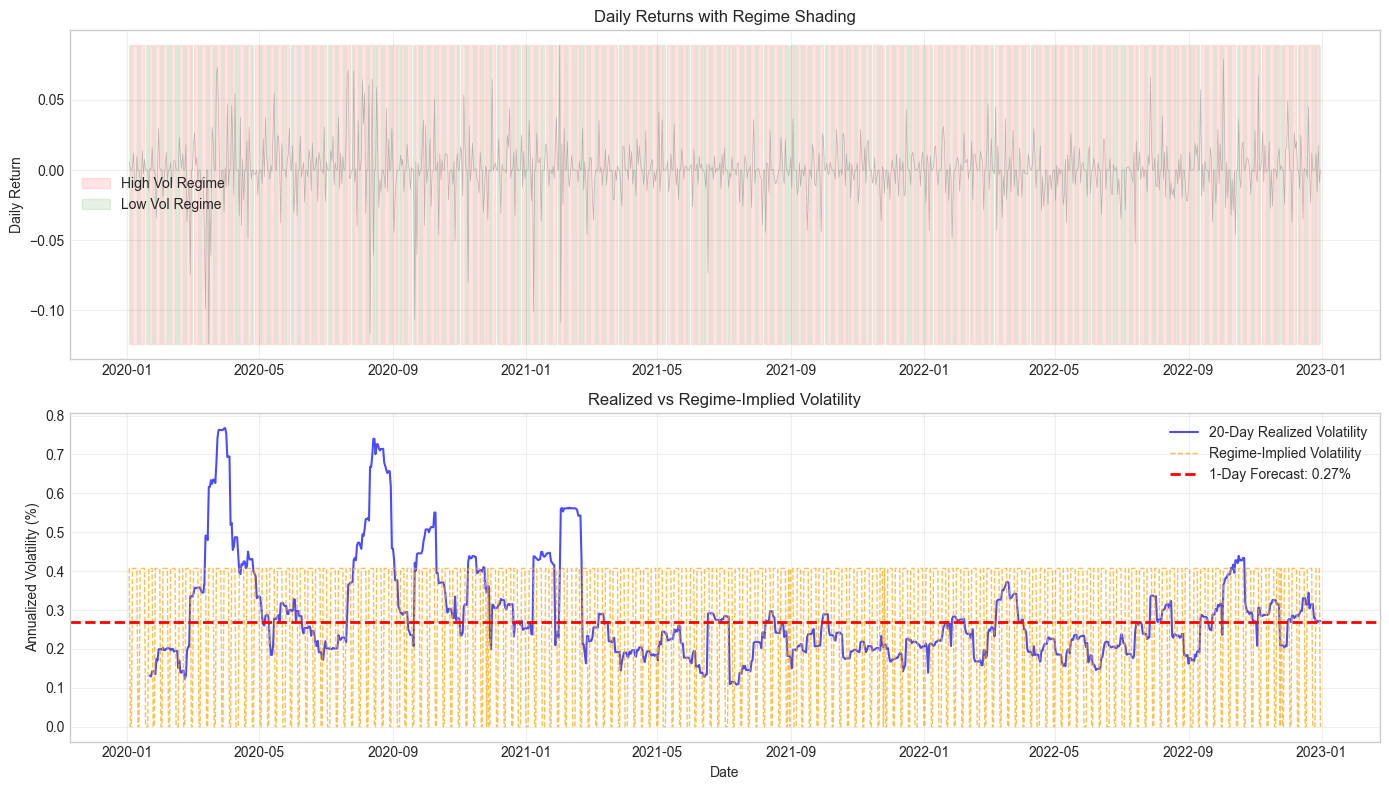

In [ ]:
def forecast_volatility(results, steps=1):
    """Forecast volatility h-steps ahead"""
    P = np.array(results.regime_transition).squeeze().T
    current_probs = results.filtered_marginal_probabilities.iloc[-1].values
    

    variances = np.array([results.params[f'sigma2[{i}]'] for i in range(results.k_regimes)])
    
    temp_p = current_probs.copy()
    vol_forecasts = []
    
    for h in range(1, steps + 1):
        temp_p = temp_p @ P
        # Expected variance is weighted average of regime variances
        expected_var = np.dot(temp_p, variances)
        vol_forecasts.append(np.sqrt(expected_var))  
    
    return np.array(vol_forecasts)

# Compute volatility forecasts for daily model
vol_forecast_1d = forecast_volatility(res_d, steps=1)[0]

# Compute realized volatility (rolling window)
window = 20  
realized_vol = ret_daily[:cutoff].rolling(window=window).std() * np.sqrt(252)  


last_realized_vol = float(realized_vol.iloc[-1])
vol_forecast_annualized = float(vol_forecast_1d * np.sqrt(252))

print("="*60)
print("VOLATILITY EVALUATION")
print("="*60)
print(f"\n1-Day Ahead Volatility Forecast (Annualized): {vol_forecast_annualized:.4f}")
print(f"Last {window}-Day Realized Volatility (Annualized): {last_realized_vol:.4f}")
print(f"\nRegime-Specific Volatilities (Annualized):")
for i in range(res_d.k_regimes):
    vol_i = np.sqrt(res_d.params[f'sigma2[{i}]']) * np.sqrt(252)
    print(f"  Regime {i}: {vol_i:.4f}")


fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Returns with regime shading
ax1 = axes[0]
ax1.plot(ret_daily[:cutoff].index, ret_daily[:cutoff], 
         color='gray', alpha=0.5, linewidth=0.5)
most_likely_regime = (res_d.smoothed_marginal_probabilities[1] > 0.5).astype(int)
most_likely_regime_arr = most_likely_regime.values if isinstance(most_likely_regime, pd.Series) else np.array(most_likely_regime)
ax1.fill_between(ret_daily[:cutoff].index, ret_daily[:cutoff].min(), ret_daily[:cutoff].max(),
                 where=(most_likely_regime_arr == 1), color='red', alpha=0.1, label='High Vol Regime')
ax1.fill_between(ret_daily[:cutoff].index, ret_daily[:cutoff].min(), ret_daily[:cutoff].max(),
                 where=(most_likely_regime_arr == 0), color='green', alpha=0.1, label='Low Vol Regime')
ax1.set_ylabel('Daily Return')
ax1.set_title('Daily Returns with Regime Shading')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Realized volatility vs regime-implied volatility
ax2 = axes[1]
ax2.plot(realized_vol.index, realized_vol, 
         color='blue', linewidth=1.5, label=f'{window}-Day Realized Volatility', alpha=0.7)

regime_vols = []
for i in range(len(ret_daily[:cutoff])):
    regime = int(most_likely_regime_arr[i])
    vol = np.sqrt(res_d.params[f'sigma2[{regime}]']) * np.sqrt(252)
    regime_vols.append(vol)

ax2.plot(ret_daily[:cutoff].index, regime_vols, 
         color='orange', linewidth=1, label='Regime-Implied Volatility', alpha=0.7, linestyle='--')

ax2.axhline(vol_forecast_annualized, color='red', linestyle='--', linewidth=2, 
            label=f'1-Day Forecast: {vol_forecast_annualized:.2f}%')
ax2.set_ylabel('Annualized Volatility (%)')
ax2.set_xlabel('Date')
ax2.set_title('Realized vs Regime-Implied Volatility')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


We can notice that high-volatility periods correspond to periods of larger return swings in the top plot. Using the analysis on the training set, we can say that :  

 By comparing the 20-Day Realized Volatility (actual price swings) against the Regime-Implied Volatility (the model's structural expectation), we can detect when the market has transitioned from a "Calm" regime to a "Crisis" state.  

 The yellow bars reveal a structural boundary around 0.4069 where the model recognizes a high-volatility regime. Significant spikes in the blue line that exceed this boundary, particularly those seen in 2020, represent tail-risk events or extreme panics that are statistically unsustainable.
 
 Currently, with the 1-Day Forecast set at 0.27%, the model suggests the market is operating in a more stabilized, moderate-risk state.

### Forecast out of sample

In [680]:
vol_forecasts_1d = []
forecast_dates = ret_daily.loc[cutoff:].index

for date in forecast_dates:
    end_loc = ret_daily.index.get_loc(date)
    train_data = ret_daily.iloc[:end_loc]

    mod = sm.tsa.MarkovRegression(
        train_data,
        k_regimes=2,
        trend='c',
        switching_variance=True
    )
    res = mod.fit(disp=False)

    vol_1d = forecast_volatility(res, steps=1)[0]
    vol_forecasts_1d.append(vol_1d)

vol_forecasts_1d = np.array(vol_forecasts_1d) * np.sqrt(252)
realized_vol_oos = ret_daily.rolling(20).std().loc[forecast_dates] * np.sqrt(252)

In [681]:
mask = ~np.isnan(realized_vol_oos.values.squeeze())

mse_vol = np.sqrt(np.mean((vol_forecasts_1d[mask] - realized_vol_oos.values[mask])**2))
mae_vol = np.mean(np.abs(vol_forecasts_1d[mask] - realized_vol_oos.values[mask]))

print("Out-of-Sample Volatility Forecast Evaluation")
print(f"RMSE: {mse_vol:.6f}")
print(f"MAE: {mae_vol:.6f}")


Out-of-Sample Volatility Forecast Evaluation
RMSE: 0.095234
MAE: 0.074521


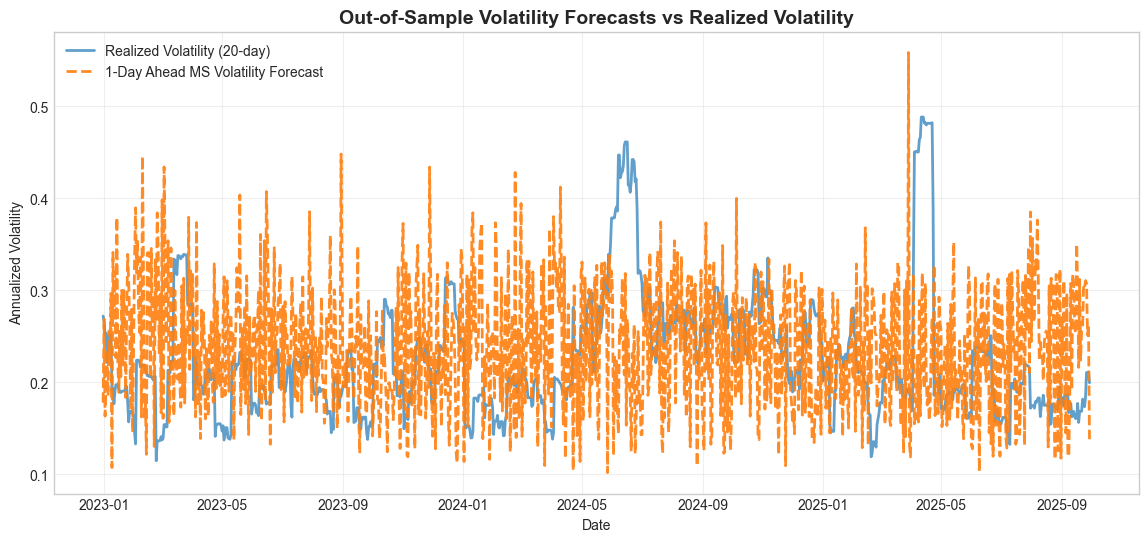

In [682]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(realized_vol_oos.index,
        realized_vol_oos,
        label='Realized Volatility (20-day)',
        linewidth=2,
        alpha=0.7)

ax.plot(realized_vol_oos.index,
        vol_forecasts_1d,
        label='1-Day Ahead MS Volatility Forecast',
        linewidth=2,
        linestyle='--',
        alpha=0.9)

ax.set_title('Out-of-Sample Volatility Forecasts vs Realized Volatility',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Annualized Volatility')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


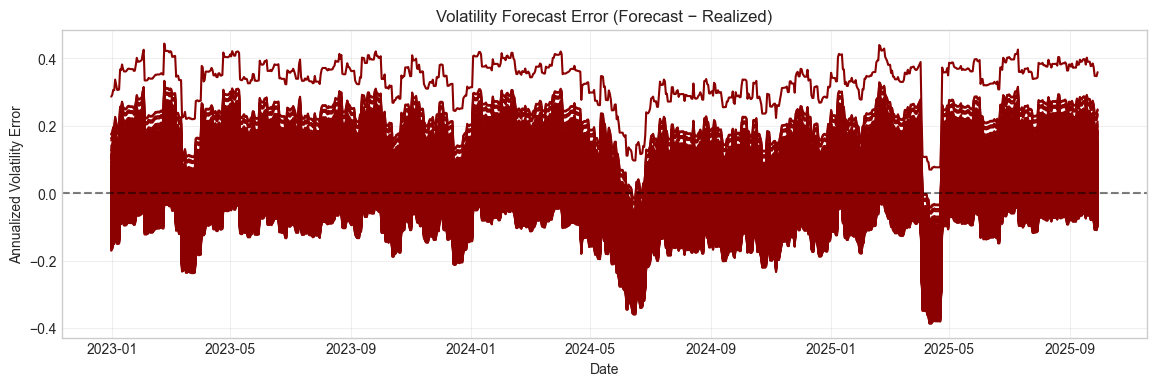

In [ ]:
forecast_error = vol_forecasts_1d - realized_vol_oos.values

plt.figure(figsize=(14,4))
plt.plot(realized_vol_oos.index, forecast_error, color='darkred')
plt.axhline(0, linestyle='--', color='black', alpha=0.5)
plt.title('Volatility Forecast Error (Forecast - Realized)')
plt.ylabel('Annualized Volatility Error')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.show()


In conclusion, we can say first that we have a RMSE of 0.095234 and MAE of 0.074521 when comparing our forecast error between true realized vol from our test set, and the implied (forecast) volatility by our model. This is a relatively good result.  
Additionnally, when plotting the error graph, we can say that we are more likely to overestimate the volatility, except in periods of big spike where we strongly underestimate it (the two big drops around may 2024 and may 2025)